/vftmp/Remi.Pages/pid218228/ipykernel_218434/1969192465.py:43: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_g = xr.open_dataset(glorys_ssh_file, decode_times=True)


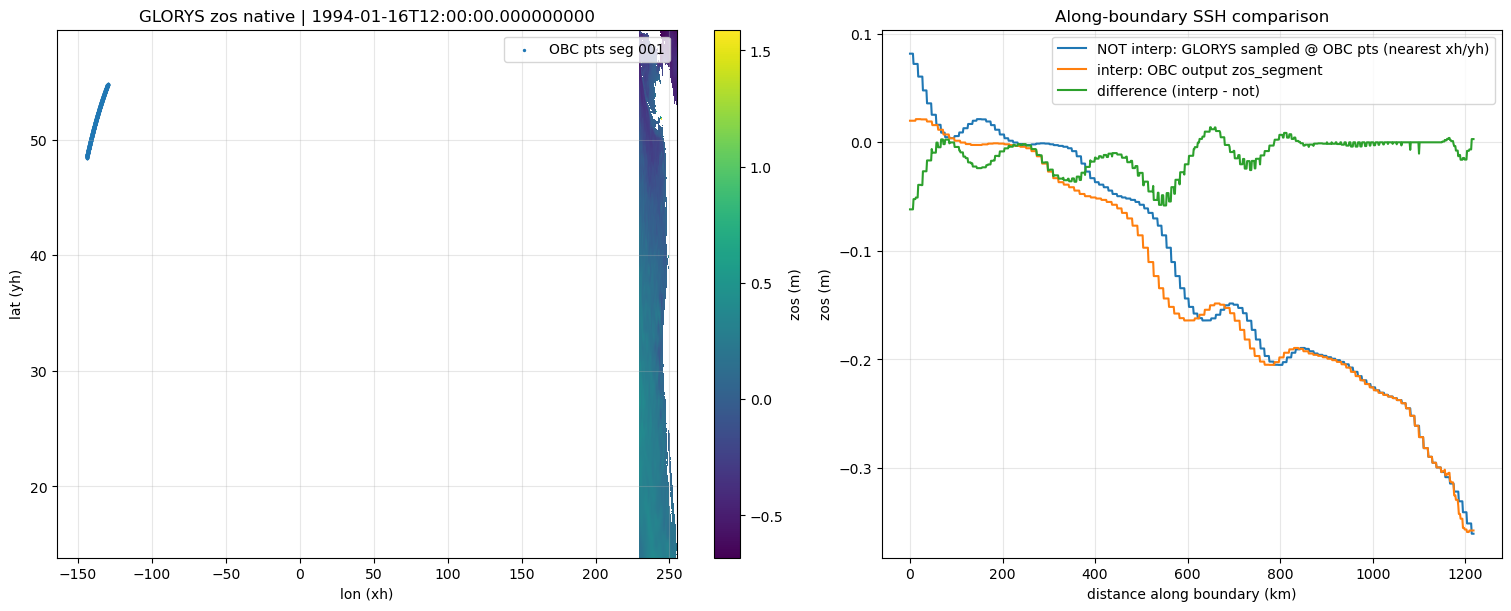

Summary stats (interp - not):
  mean: -0.011863516
  std : 0.015508769
  min : -0.061774924
  max : 0.013869807


In [15]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

year = 1994
seg = "001"
time_index = 0

glorys_dir = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/"
glorys_ssh_file = f"{glorys_dir}/{year}0101crpt_forc/ocean_month.nc"
obc_interp_file = f"./outputs_CGOA_feb26/zos_{int(seg):03d}_{year}.nc"  # adjust if needed

def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def nearest_1d_index(grid_1d, values):
    """
    grid_1d: sorted 1D array
    values: array of target values
    returns indices into grid_1d for nearest neighbor
    """
    grid = np.asarray(grid_1d)
    v = np.asarray(values)

    # handle periodic lon if needed (you are in 0..360 already, so likely fine)
    # v = (v + 360) % 360

    # insertion positions
    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)

    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    out = (idx - 1) + choose_right.astype(int)
    return out

# --- open GLORYS ---
ds_g = xr.open_dataset(glorys_ssh_file, decode_times=True)
zos_g = ds_g["zos"].isel(time=time_index)     # dims (yh, xh)
xh = ds_g["xh"].values
yh = ds_g["yh"].values

# --- open OBC (interp output) ---
ds_o = xr.open_dataset(obc_interp_file, decode_times=True)

zos_name = _find_var(ds_o, [f"zos_segment_{seg}", "zos_segment_001", "zos"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

if any(v is None for v in [zos_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in {obc_interp_file}. Vars: {list(ds_o.variables)}")

zos_o = ds_o[zos_name].isel(time=time_index).squeeze(drop=True).values
lon_o = ds_o[lon_name].squeeze(drop=True).values
lat_o = ds_o[lat_name].squeeze(drop=True).values

# --- NOT interp: sample GLORYS zos at OBC points using nearest (xh,yh) ---
ix = nearest_1d_index(xh, lon_o)
iy = nearest_1d_index(yh, lat_o)

zos_g_at_obc = zos_g.values[iy, ix]  # 1D along boundary

# Along-boundary distance (km)
R = 6371.0
lonr = np.deg2rad(lon_o)
latr = np.deg2rad(lat_o)
dlon = np.diff(lonr)
dlat = np.diff(latr)
a = np.sin(dlat/2)**2 + np.cos(latr[:-1])*np.cos(latr[1:])*np.sin(dlon/2)**2
d = 2*R*np.arcsin(np.sqrt(a))
s_km = np.concatenate([[0], np.cumsum(d)])

# --- plot ---
fig, ax = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

# Left: native map
pm = ax[0].pcolormesh(xh, yh, zos_g.values, shading="nearest")
ax[0].scatter(lon_o, lat_o, s=8, marker=".", label=f"OBC pts seg {seg}")
ax[0].set_title(f"GLORYS zos native | {str(ds_g['time'].isel(time=time_index).values)}")
ax[0].set_xlabel("lon (xh)")
ax[0].set_ylabel("lat (yh)")
ax[0].grid(True, alpha=0.3)
ax[0].legend(loc="best")
cb = plt.colorbar(pm, ax=ax[0])
cb.set_label("zos (m)")

# Right: 1D compare
ax[1].plot(s_km, zos_g_at_obc, label="NOT interp: GLORYS sampled @ OBC pts (nearest xh/yh)")
ax[1].plot(s_km, zos_o,       label="interp: OBC output zos_segment")
ax[1].plot(s_km, zos_o - zos_g_at_obc, label="difference (interp - not)")
ax[1].set_title("Along-boundary SSH comparison")
ax[1].set_xlabel("distance along boundary (km)")
ax[1].set_ylabel("zos (m)")
ax[1].grid(True, alpha=0.3)
ax[1].legend(loc="best")

plt.show()

print("Summary stats (interp - not):")
diff = zos_o - zos_g_at_obc
print("  mean:", np.nanmean(diff))
print("  std :", np.nanstd(diff))
print("  min :", np.nanmin(diff))
print("  max :", np.nanmax(diff))

/vftmp/Remi.Pages/pid218228/ipykernel_218434/827059998.py:51: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_g = xr.open_dataset(glorys_ssh_file, decode_times=True)


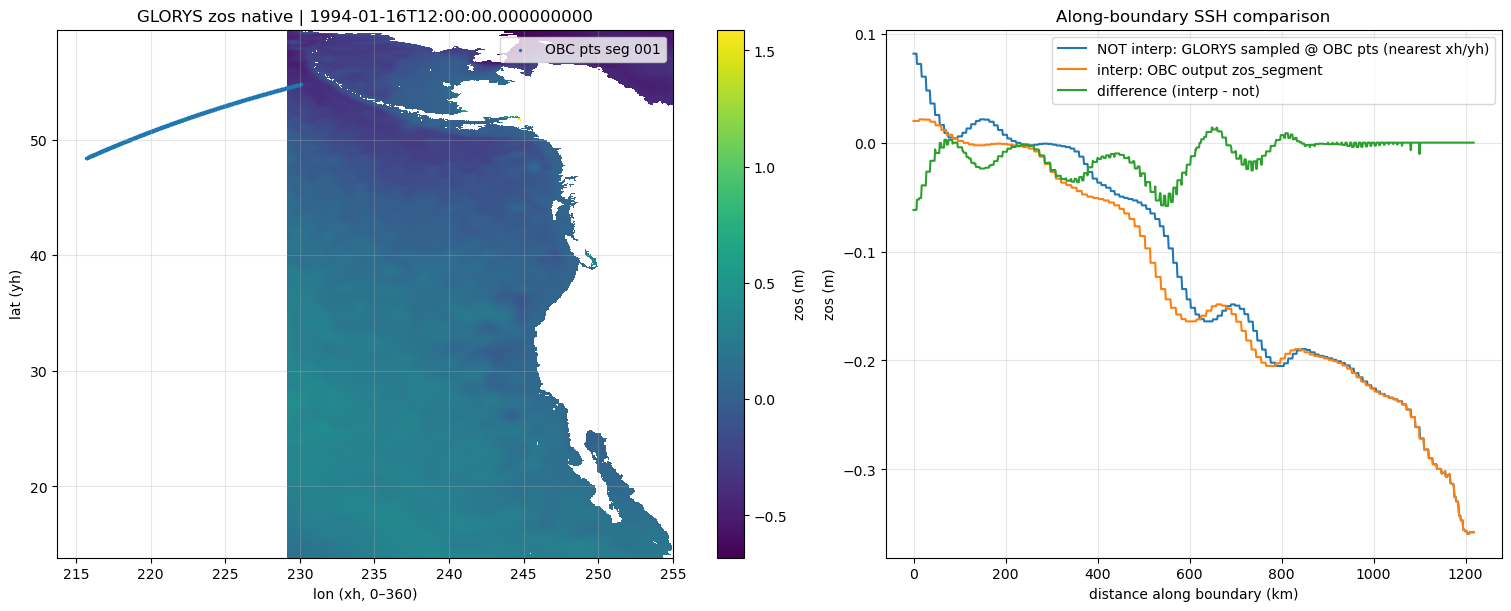

Lon ranges:
  GLORYS xh range: 229.15 .. 254.96
  OBC lon range   : -144.30 .. -129.91
  Using OBC lon for GLORYS sampling range: 215.70 .. 230.09

Summary stats (interp - not):
  mean: -0.01158189494162798
  std : 0.015585169196128845
  min : -0.06177492439746857
  max : 0.013869807124137878


In [5]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

year = 1994
seg = "001"
time_index = 0

glorys_dir = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/"
glorys_ssh_file = f"{glorys_dir}/{year}0101crpt_forc/ocean_month.nc"
obc_interp_file = f"./outputs_CGOA_feb26/zos_{int(seg):03d}_{year}.nc"  # adjust if needed


def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None


def lon_180_to_360(lon):
    lon = np.asarray(lon)
    return lon % 360


def lon_360_to_180(lon):
    lon = np.asarray(lon)
    return ((lon + 180) % 360) - 180


def nearest_1d_index(grid_1d, values):
    """
    grid_1d: sorted 1D array
    values: array of target values
    returns indices into grid_1d for nearest neighbor
    """
    grid = np.asarray(grid_1d)
    v = np.asarray(values)

    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)

    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    out = (idx - 1) + choose_right.astype(int)
    return out


# --- open GLORYS ---
ds_g = xr.open_dataset(glorys_ssh_file, decode_times=True)
zos_g = ds_g["zos"].isel(time=time_index)  # dims (yh, xh)
xh = ds_g["xh"].values
yh = ds_g["yh"].values

tstamp = ds_g["time"].isel(time=time_index).values

# --- open OBC (interp output) ---
ds_o = xr.open_dataset(obc_interp_file, decode_times=True)

zos_name = _find_var(ds_o, [f"zos_segment_{seg}", "zos_segment_001", "zos"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

if any(v is None for v in [zos_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in {obc_interp_file}. Vars: {list(ds_o.variables)}")

zos_o = ds_o[zos_name].isel(time=time_index).squeeze(drop=True).values
lon_o = ds_o[lon_name].squeeze(drop=True).values
lat_o = ds_o[lat_name].squeeze(drop=True).values


# -------------------------------------------------------------------
# Make OBC lon consistent with GLORYS lon axis for sampling & plotting
# GLORYS here is 0..360 (xh ~ 229..255), so convert OBC to 0..360 if needed
# -------------------------------------------------------------------
xh_min, xh_max = np.nanmin(xh), np.nanmax(xh)
obc_min, obc_max = np.nanmin(lon_o), np.nanmax(lon_o)

# Heuristic:
# If GLORYS is 0..360-like and OBC includes negatives, convert OBC -> 0..360
use_lon_o_for_glorys = lon_o.copy()
if (xh_min >= 0) and (obc_min < 0):
    use_lon_o_for_glorys = lon_180_to_360(lon_o)

# (Optional other direction if you ever need it)
# if (xh_min < 0) and (obc_min >= 0):
#     use_lon_o_for_glorys = lon_360_to_180(lon_o)

# Ensure monotonic xh for searchsorted (it should already be sorted)
# but keep it safe:
if not np.all(np.diff(xh) > 0):
    order = np.argsort(xh)
    xh_sorted = xh[order]
    zos_g_vals = zos_g.values[:, order]
else:
    xh_sorted = xh
    zos_g_vals = zos_g.values


# --- NOT interp: sample GLORYS zos at OBC points using nearest (xh,yh) ---
ix = nearest_1d_index(xh_sorted, use_lon_o_for_glorys)
iy = nearest_1d_index(yh, lat_o)

zos_g_at_obc = zos_g_vals[iy, ix]  # 1D along boundary


# Along-boundary distance (km) computed from ORIGINAL lon/lat (no conversion)
R = 6371.0
lonr = np.deg2rad(lon_o)
latr = np.deg2rad(lat_o)
dlon = np.diff(lonr)
dlat = np.diff(latr)
a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
d = 2 * R * np.arcsin(np.sqrt(a))
s_km = np.concatenate([[0], np.cumsum(d)])


# --- plot ---
fig, ax = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

# Left: native map (GLORYS) + OBC points (converted to GLORYS convention if needed)
pm = ax[0].pcolormesh(xh, yh, zos_g.values, shading="nearest")
ax[0].scatter(use_lon_o_for_glorys, lat_o, s=8, marker=".", label=f"OBC pts seg {seg}")
ax[0].set_title(f"GLORYS zos native | {str(tstamp)}")
ax[0].set_xlabel("lon (xh, 0–360)")
ax[0].set_ylabel("lat (yh)")
ax[0].grid(True, alpha=0.3)
ax[0].legend(loc="best")
cb = plt.colorbar(pm, ax=ax[0])
cb.set_label("zos (m)")

# Right: 1D compare
ax[1].plot(s_km, zos_g_at_obc, label="NOT interp: GLORYS sampled @ OBC pts (nearest xh/yh)")
ax[1].plot(s_km, zos_o,        label="interp: OBC output zos_segment")
ax[1].plot(s_km, zos_o - zos_g_at_obc, label="difference (interp - not)")
ax[1].set_title("Along-boundary SSH comparison")
ax[1].set_xlabel("distance along boundary (km)")
ax[1].set_ylabel("zos (m)")
ax[1].grid(True, alpha=0.3)
ax[1].legend(loc="best")

plt.show()

print("Lon ranges:")
print(f"  GLORYS xh range: {xh_min:.2f} .. {xh_max:.2f}")
print(f"  OBC lon range   : {obc_min:.2f} .. {obc_max:.2f}")
print("  Using OBC lon for GLORYS sampling range:",
      f"{np.nanmin(use_lon_o_for_glorys):.2f} .. {np.nanmax(use_lon_o_for_glorys):.2f}")

print("\nSummary stats (interp - not):")
diff = zos_o - zos_g_at_obc
print("  mean:", float(np.nanmean(diff)))
print("  std :", float(np.nanstd(diff)))
print("  min :", float(np.nanmin(diff)))
print("  max :", float(np.nanmax(diff)))

In [6]:
print("GLORYS lon min/max:", float(xh.min()), float(xh.max()))
print("OBC lon min/max (converted to 0-360):",
      float(lon_180_to_360(lon_o).min()),
      float(lon_180_to_360(lon_o).max()))

GLORYS lon min/max: 229.14501953125 254.96383666992188
OBC lon min/max (converted to 0-360): 215.69998168945312 230.0894317626953


/vftmp/Remi.Pages/pid179295/ipykernel_219121/3489103953.py:34: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_g = xr.open_dataset(glorys_ssh_file, decode_times=True)


Coverage check:
  NEP10 lon range (deg): -130.85 .. -105.04
  NEP10 lat range (deg): 13.86 .. 59.52
  OBC  lon range (deg): -144.30 .. -129.91
  OBC  lat range (deg): 48.42 .. 54.81
  Points inside source domain: 56 / 961


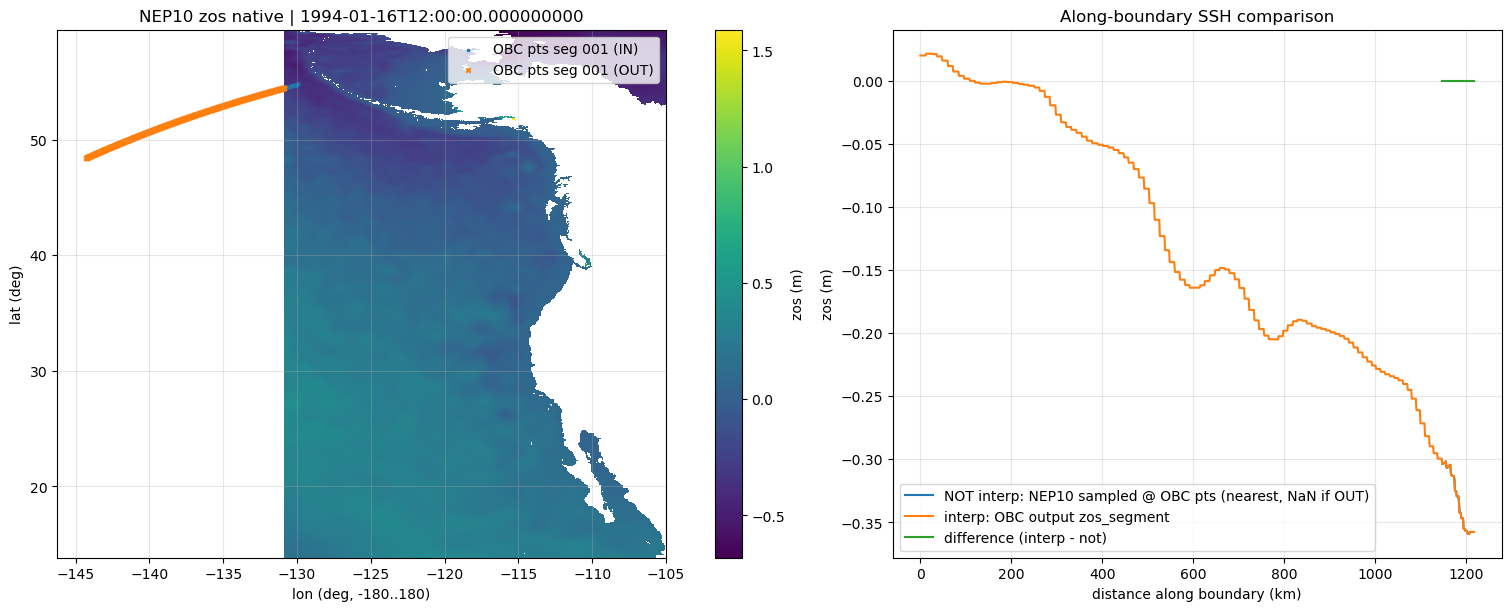

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

year = 1994
seg = "001"
time_index = 0

glorys_dir = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/"
glorys_ssh_file = f"{glorys_dir}/{year}0101crpt_forc/ocean_month.nc"
obc_interp_file = f"./outputs_CGOA_feb26/zos_{int(seg):03d}_{year}.nc"

def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_360_to_180(lon):
    lon = np.asarray(lon)
    return ((lon + 180) % 360) - 180

def nearest_1d_index_sorted(grid_1d_sorted, values):
    grid = np.asarray(grid_1d_sorted)
    v = np.asarray(values)
    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)
    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    return (idx - 1) + choose_right.astype(int)

# --- open NEP10 ("glorys") ---
ds_g = xr.open_dataset(glorys_ssh_file, decode_times=True)
zos_g = ds_g["zos"].isel(time=time_index)  # dims (yh, xh)
xh_360 = ds_g["xh"].values
yh = ds_g["yh"].values
tstamp = ds_g["time"].isel(time=time_index).values

# convert xh to [-180,180] and reorder field accordingly
xh_180 = lon_360_to_180(xh_360)
order = np.argsort(xh_180)
xh_180s = xh_180[order]
zos_g_vals = zos_g.values[:, order]  # reorder x dimension

# --- open OBC (interp output) ---
ds_o = xr.open_dataset(obc_interp_file, decode_times=True)
zos_name = _find_var(ds_o, [f"zos_segment_{seg}", "zos_segment_001", "zos"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])
if any(v is None for v in [zos_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in {obc_interp_file}. Vars: {list(ds_o.variables)}")

zos_o = ds_o[zos_name].isel(time=time_index).squeeze(drop=True).values
lon_o = ds_o[lon_name].squeeze(drop=True).values
lat_o = ds_o[lat_name].squeeze(drop=True).values

# --- determine which OBC points are inside NEP10 source coverage ---
in_lon = (lon_o >= xh_180s.min()) & (lon_o <= xh_180s.max())
in_lat = (lat_o >= yh.min()) & (lat_o <= yh.max())
in_domain = in_lon & in_lat

print("Coverage check:")
print(f"  NEP10 lon range (deg): {xh_180s.min():.2f} .. {xh_180s.max():.2f}")
print(f"  NEP10 lat range (deg): {yh.min():.2f} .. {yh.max():.2f}")
print(f"  OBC  lon range (deg): {np.nanmin(lon_o):.2f} .. {np.nanmax(lon_o):.2f}")
print(f"  OBC  lat range (deg): {np.nanmin(lat_o):.2f} .. {np.nanmax(lat_o):.2f}")
print(f"  Points inside source domain: {in_domain.sum()} / {in_domain.size}")

# --- sample NEP10 zos at OBC points (nearest) ONLY where in-domain ---
zos_g_at_obc = np.full_like(zos_o, np.nan, dtype=float)

ix = nearest_1d_index_sorted(xh_180s, lon_o[in_domain])
iy = nearest_1d_index_sorted(yh,      lat_o[in_domain])
zos_g_at_obc[in_domain] = zos_g_vals[iy, ix]

# Along-boundary distance (km)
R = 6371.0
lonr = np.deg2rad(lon_o)
latr = np.deg2rad(lat_o)
dlon = np.diff(lonr)
dlat = np.diff(latr)
a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
d = 2 * R * np.arcsin(np.sqrt(a))
s_km = np.concatenate([[0], np.cumsum(d)])

# --- plot ---
fig, ax = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

pm = ax[0].pcolormesh(xh_180s, yh, zos_g_vals, shading="nearest")
ax[0].scatter(lon_o[in_domain],  lat_o[in_domain],  s=10, marker=".", label=f"OBC pts seg {seg} (IN)")
ax[0].scatter(lon_o[~in_domain], lat_o[~in_domain], s=10, marker="x", label=f"OBC pts seg {seg} (OUT)")
ax[0].set_title(f"NEP10 zos native | {str(tstamp)}")
ax[0].set_xlabel("lon (deg, -180..180)")
ax[0].set_ylabel("lat (deg)")
ax[0].grid(True, alpha=0.3)
ax[0].legend(loc="best")
cb = plt.colorbar(pm, ax=ax[0])
cb.set_label("zos (m)")

ax[1].plot(s_km, zos_g_at_obc, label="NOT interp: NEP10 sampled @ OBC pts (nearest, NaN if OUT)")
ax[1].plot(s_km, zos_o,        label="interp: OBC output zos_segment")
ax[1].plot(s_km, zos_o - zos_g_at_obc, label="difference (interp - not)")
ax[1].set_title("Along-boundary SSH comparison")
ax[1].set_xlabel("distance along boundary (km)")
ax[1].set_ylabel("zos (m)")
ax[1].grid(True, alpha=0.3)
ax[1].legend(loc="best")

plt.show()

/vftmp/Remi.Pages/pid218228/ipykernel_218434/3535244203.py:50: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_g = xr.open_dataset(glorys_ssh_file, decode_times=True)


=== RANGES ===
Source lon mode: 0_360
Source xh min/max: 229.14501953125 254.96383666992188
Source yh min/max: 13.861797332763672 59.5235710144043
OBC lon raw min/max: -144.30001831054688 -129.9105682373047
OBC lon used min/max: 215.69998168945312 230.0894317626953
OBC lat min/max: 48.423954010009766 54.81351089477539
Points inside bbox: 56 / 961


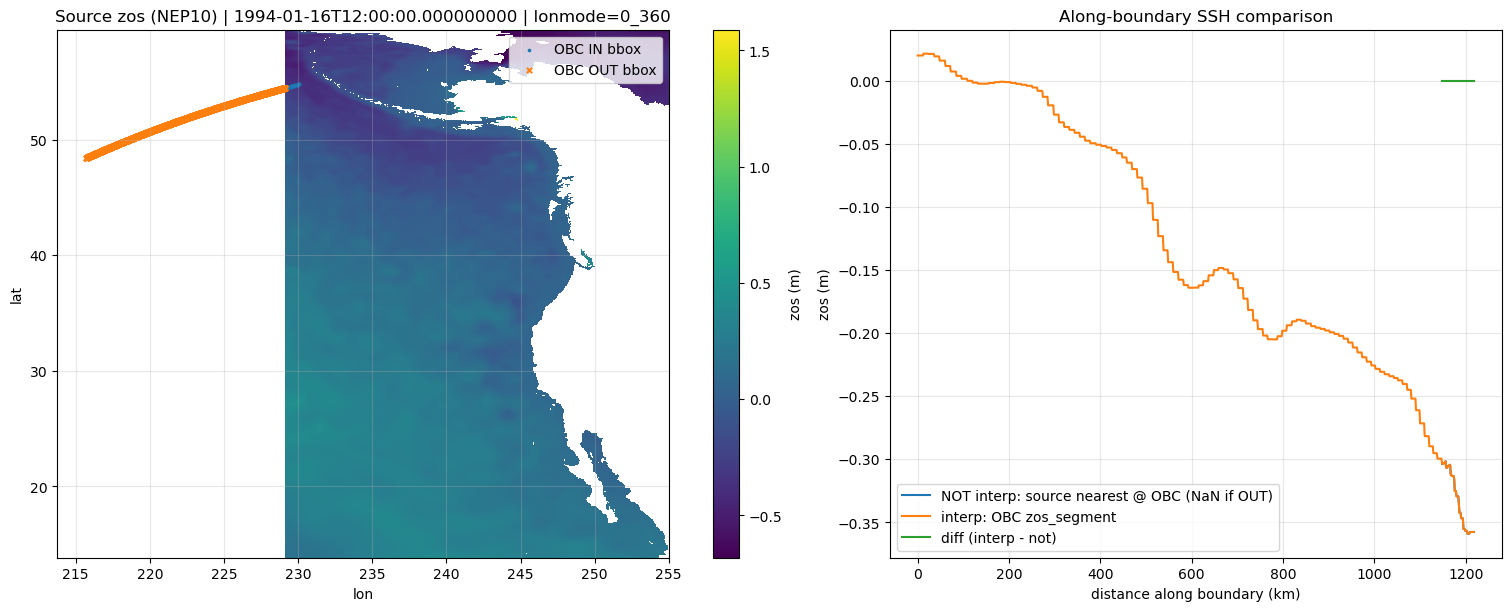


=== STATS (interp - not) ===
finite points: 56 / 961
  mean: 0.0
  std : 0.0
  min : 0.0
  max : 0.0


In [4]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

year = 1994
seg = "001"
time_index = 0

glorys_dir = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/"
glorys_ssh_file = f"{glorys_dir}/{year}0101crpt_forc/ocean_month.nc"
obc_interp_file = f"./outputs_CGOA_feb26/zos_{int(seg):03d}_{year}.nc"

def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_180_to_360(lon):
    lon = np.asarray(lon)
    return lon % 360

def lon_360_to_180(lon):
    lon = np.asarray(lon)
    return ((lon + 180) % 360) - 180

def nearest_1d_index_sorted(grid_1d_sorted, values):
    grid = np.asarray(grid_1d_sorted)
    v = np.asarray(values)
    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)
    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    return (idx - 1) + choose_right.astype(int)

def haversine_km(lon, lat):
    R = 6371.0
    lonr = np.deg2rad(np.asarray(lon))
    latr = np.deg2rad(np.asarray(lat))
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
    d = 2*R*np.arcsin(np.sqrt(a))
    return np.concatenate([[0], np.cumsum(d)])

# -----------------------------
# Open SOURCE (NEP10 "glorys")
# -----------------------------
ds_g = xr.open_dataset(glorys_ssh_file, decode_times=True)

zos_g = ds_g["zos"].isel(time=time_index)  # (yh, xh)
xh = ds_g["xh"].values
yh = ds_g["yh"].values
tstamp = ds_g["time"].isel(time=time_index).values

# Detect source lon convention
src_is_0360 = (np.nanmin(xh) >= 0) and (np.nanmax(xh) > 180)
src_lon_mode = "0_360" if src_is_0360 else "neg180_180"

# Ensure xh is sorted
order = np.argsort(xh)
xh_s = xh[order]
zos_vals = zos_g.values[:, order]

# -----------------------------
# Open OBC output
# -----------------------------
ds_o = xr.open_dataset(obc_interp_file, decode_times=True)

zos_name = _find_var(ds_o, [f"zos_segment_{seg}", "zos_segment_001", "zos"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

if any(v is None for v in [zos_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in {obc_interp_file}. Vars: {list(ds_o.variables)}")

zos_o = ds_o[zos_name].isel(time=time_index).squeeze(drop=True).values
lon_o_raw = ds_o[lon_name].squeeze(drop=True).values
lat_o = ds_o[lat_name].squeeze(drop=True).values

# Normalize OBC lon to match source lon convention
if src_lon_mode == "0_360":
    lon_o = lon_180_to_360(lon_o_raw)
else:
    lon_o = lon_360_to_180(lon_o_raw)

# -----------------------------
# Coverage check (bbox)
# -----------------------------
in_lon = (lon_o >= np.nanmin(xh_s)) & (lon_o <= np.nanmax(xh_s))
in_lat = (lat_o >= np.nanmin(yh)) & (lat_o <= np.nanmax(yh))
in_domain = in_lon & in_lat

print("=== RANGES ===")
print("Source lon mode:", src_lon_mode)
print("Source xh min/max:", float(np.nanmin(xh_s)), float(np.nanmax(xh_s)))
print("Source yh min/max:", float(np.nanmin(yh)), float(np.nanmax(yh)))
print("OBC lon raw min/max:", float(np.nanmin(lon_o_raw)), float(np.nanmax(lon_o_raw)))
print("OBC lon used min/max:", float(np.nanmin(lon_o)), float(np.nanmax(lon_o)))
print("OBC lat min/max:", float(np.nanmin(lat_o)), float(np.nanmax(lat_o)))
print("Points inside bbox:", int(in_domain.sum()), "/", int(in_domain.size))
print("==============")

# -----------------------------
# Nearest sample SOURCE at OBC points (NaN if out)
# -----------------------------
zos_g_at_obc = np.full_like(zos_o, np.nan, dtype=float)
ix = nearest_1d_index_sorted(xh_s, lon_o[in_domain])
iy = nearest_1d_index_sorted(yh,   lat_o[in_domain])
zos_g_at_obc[in_domain] = zos_vals[iy, ix]

# distance axis (use RAW lon/lat for geometry)
s_km = haversine_km(lon_o_raw, lat_o)

# diff
diff = zos_o - zos_g_at_obc

# -----------------------------
# PLOTS
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

# Map panel in SOURCE lon mode
pm = ax[0].pcolormesh(xh_s, yh, zos_vals, shading="nearest")
ax[0].scatter(lon_o[in_domain],  lat_o[in_domain],  s=10, marker=".", label="OBC IN bbox")
ax[0].scatter(lon_o[~in_domain], lat_o[~in_domain], s=14, marker="x", label="OBC OUT bbox")
ax[0].set_title(f"Source zos (NEP10) | {str(tstamp)} | lonmode={src_lon_mode}")
ax[0].set_xlabel("lon")
ax[0].set_ylabel("lat")
ax[0].grid(True, alpha=0.3)
ax[0].legend(loc="best")
cb = plt.colorbar(pm, ax=ax[0])
cb.set_label("zos (m)")

# Along-boundary
ax[1].plot(s_km, zos_g_at_obc, label="NOT interp: source nearest @ OBC (NaN if OUT)")
ax[1].plot(s_km, zos_o,        label="interp: OBC zos_segment")
ax[1].plot(s_km, diff,         label="diff (interp - not)")
ax[1].set_title("Along-boundary SSH comparison")
ax[1].set_xlabel("distance along boundary (km)")
ax[1].set_ylabel("zos (m)")
ax[1].grid(True, alpha=0.3)
ax[1].legend(loc="best")

plt.show()

# -----------------------------
# STATS
# -----------------------------
finite = np.isfinite(diff)
print("\n=== STATS (interp - not) ===")
print("finite points:", int(finite.sum()), "/", int(diff.size))
if finite.any():
    print("  mean:", float(np.nanmean(diff)))
    print("  std :", float(np.nanstd(diff)))
    print("  min :", float(np.nanmin(diff)))
    print("  max :", float(np.nanmax(diff)))

/vftmp/Remi.Pages/pid218228/ipykernel_218434/481929578.py:93: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_src = xr.open_dataset(src_file, decode_times=True)


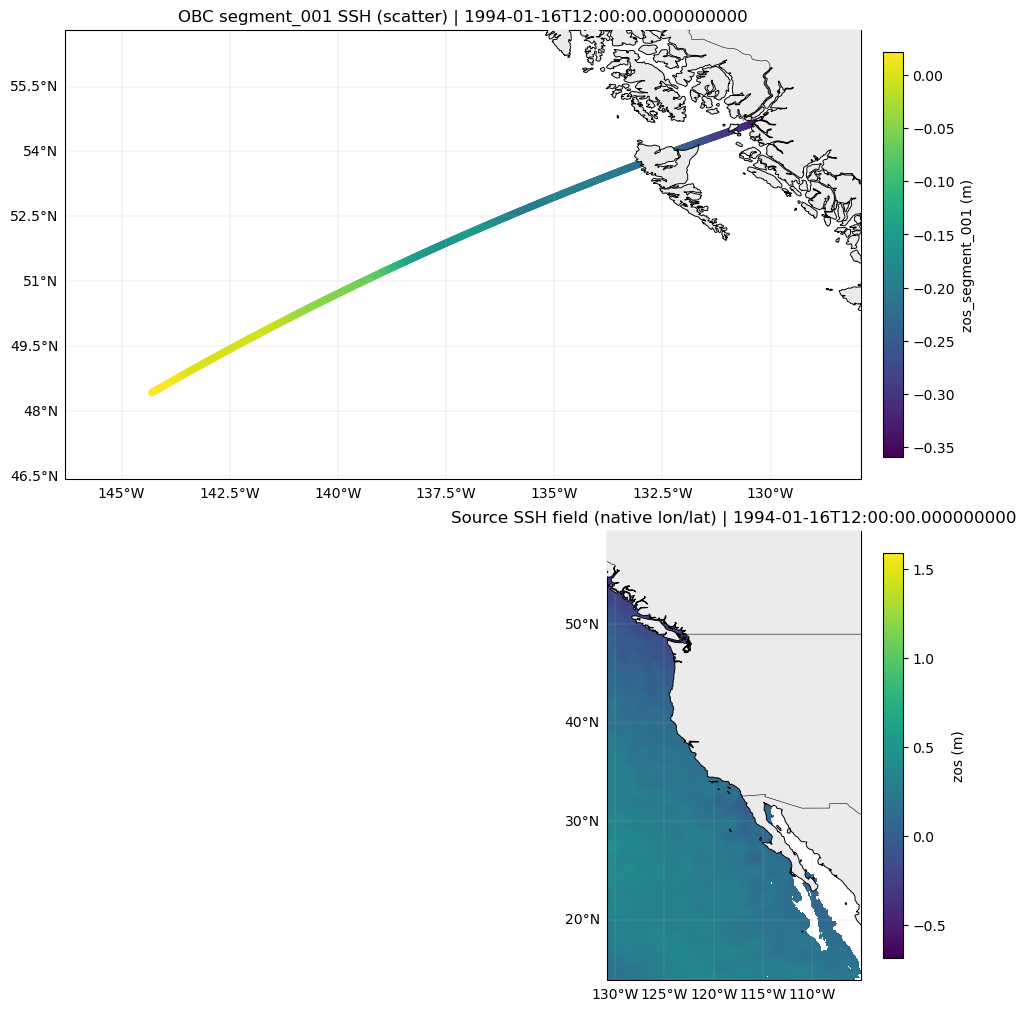

In [13]:
#!/usr/bin/env python3
"""
Two-panel Cartopy plot:

TOP:
  - OBC segment_001 SSH as scatter on a normal lon(-180..180) map (like your first plot).

BOTTOM:
  - NEP SSH field plotted in its *native* lon/lat (typically 0..360 for xh),
    using a Cartopy PlateCarree projection with central_longitude=180 so the
    0..360 grid does NOT get cut/weird at the map edge.

This avoids the "NEP disappeared / vertical cutoff" artifact which is purely
a plotting/projection + lon convention issue.
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# =========================
# EDIT THESE
# =========================
time_index = 0

obc_file = "./outputs_CGOA_feb26/zos_001_1994.nc"
src_file = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/19940101crpt_forc/ocean_month.nc"


# =========================
# Helpers
# =========================
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_180_to_360(lon):
    lon = np.asarray(lon)
    return lon % 360

def lon_360_to_180(lon):
    lon = np.asarray(lon)
    return ((lon + 180) % 360) - 180

def is_0_360(lon):
    lon = np.asarray(lon)
    return (np.nanmin(lon) >= 0) and (np.nanmax(lon) > 180)

def add_map(ax):
    ax.add_feature(cfeature.LAND, zorder=10, facecolor="0.92")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=11)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=11)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False


# =========================
# Load OBC (top panel)
# =========================
ds_obc = xr.open_dataset(obc_file, decode_times=True)

zos_name = _find_var(ds_obc, ["zos_segment_001", "zos", "ssh"])
lon_name = _find_var(ds_obc, ["lon_segment_001", "lon"])
lat_name = _find_var(ds_obc, ["lat_segment_001", "lat"])
if zos_name is None or lon_name is None or lat_name is None:
    raise ValueError(f"Missing vars in {obc_file}. Vars={list(ds_obc.variables)}")

zos_obc = ds_obc[zos_name].isel(time=time_index).squeeze(drop=True).values
lon_obc = ds_obc[lon_name].squeeze(drop=True).values
lat_obc = ds_obc[lat_name].squeeze(drop=True).values

# flatten
zos_obc = np.asarray(zos_obc).reshape(-1)
lon_obc = np.asarray(lon_obc).reshape(-1)
lat_obc = np.asarray(lat_obc).reshape(-1)

t_obc = ds_obc["time"].isel(time=time_index).values if "time" in ds_obc else None

# For TOP panel plotting in -180..180
lon_obc_top = lon_360_to_180(lon_obc) if is_0_360(lon_obc) else lon_obc


# =========================
# Load SOURCE/NEP (bottom panel)
# =========================
ds_src = xr.open_dataset(src_file, decode_times=True)

src_zos_name = _find_var(ds_src, ["zos", "ssh"])
xh_name = _find_var(ds_src, ["xh", "lon", "longitude"])
yh_name = _find_var(ds_src, ["yh", "lat", "latitude"])

if src_zos_name is None:
    raise ValueError(f"Could not find zos/ssh in {src_file}. data_vars={list(ds_src.data_vars)}")
if xh_name is None or yh_name is None:
    raise ValueError(f"Could not find xh/yh in {src_file}. coords={list(ds_src.coords)}")

src = ds_src[src_zos_name].isel(time=time_index)
xh = ds_src[xh_name].values          # native (often 0..360)
yh = ds_src[yh_name].values
src_vals = src.values
if src_vals.ndim != 2:
    raise ValueError(f"Expected 2D source after isel(time). Got {src_vals.shape}, dims={src.dims}")

t_src = ds_src["time"].isel(time=time_index).values if "time" in ds_src else None


# =========================
# Figure + projections
# =========================
# TOP: normal lon(-180..180) view
proj_top = ccrs.PlateCarree()

# BOTTOM: keep NEP in native 0..360 view
# Use a PlateCarree map centered on 180 so 0..360 data doesn't "cut" at the edges.
proj_bot = ccrs.PlateCarree(central_longitude=180)

# Data transform for lon/lat grids is still regular PlateCarree (geodetic lon/lat)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1])

# =========================
# TOP panel: OBC scatter (lon -180..180)
# =========================
ax0 = fig.add_subplot(gs[0, 0], projection=proj_top)
add_map(ax0)

# Set extent around the OBC line (in -180..180)
lon0_min, lon0_max = np.nanmin(lon_obc_top), np.nanmax(lon_obc_top)
lat0_min, lat0_max = np.nanmin(lat_obc), np.nanmax(lat_obc)
ax0.set_extent([lon0_min - 2, lon0_max + 2, lat0_min - 2, lat0_max + 2], crs=data_crs)

sc = ax0.scatter(
    lon_obc_top, lat_obc,
    c=zos_obc, s=18, marker="o",
    transform=data_crs
)
ax0.set_title(f"OBC segment_001 SSH (scatter) | {str(t_obc)}" if t_obc is not None else "OBC segment_001 SSH (scatter)")
cb0 = plt.colorbar(sc, ax=ax0, orientation="vertical", shrink=0.9, pad=0.02)
cb0.set_label(f"{zos_name} (m)")


# =========================
# BOTTOM panel: NEP pcolormesh in native lon/lat
# =========================
ax1 = fig.add_subplot(gs[1, 0], projection=proj_bot)
add_map(ax1)

# IMPORTANT: extent must be in the SAME CRS as data_crs but consistent with native lon:
# If xh is 0..360, use that directly in set_extent.
ax1.set_extent([float(np.nanmin(xh)), float(np.nanmax(xh)),
                float(np.nanmin(yh)), float(np.nanmax(yh))],
               crs=data_crs)

pm = ax1.pcolormesh(
    xh, yh, src_vals,
    shading="nearest",
    transform=data_crs
)
ax1.set_title(f"Source SSH field (native lon/lat) | {str(t_src)}" if t_src is not None else "Source SSH field (native lon/lat)")
cb1 = plt.colorbar(pm, ax=ax1, orientation="vertical", shrink=0.9, pad=0.02)
cb1.set_label(f"{src_zos_name} (m)")

plt.show()

/vftmp/Remi.Pages/pid218228/ipykernel_218434/2524593962.py:96: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_s = xr.open_dataset(src_file, decode_times=True)


=== RANGE CHECK ===
Source lon min/max: 229.14501953125 254.96383666992188
Source lat min/max: 13.861797332763672 59.5235710144043
OBC lon  min/max (matched): 215.69998168945312 230.0894317626953
OBC lat  min/max: 48.423954010009766 54.81351089477539
Points inside source bbox: 56 / 961


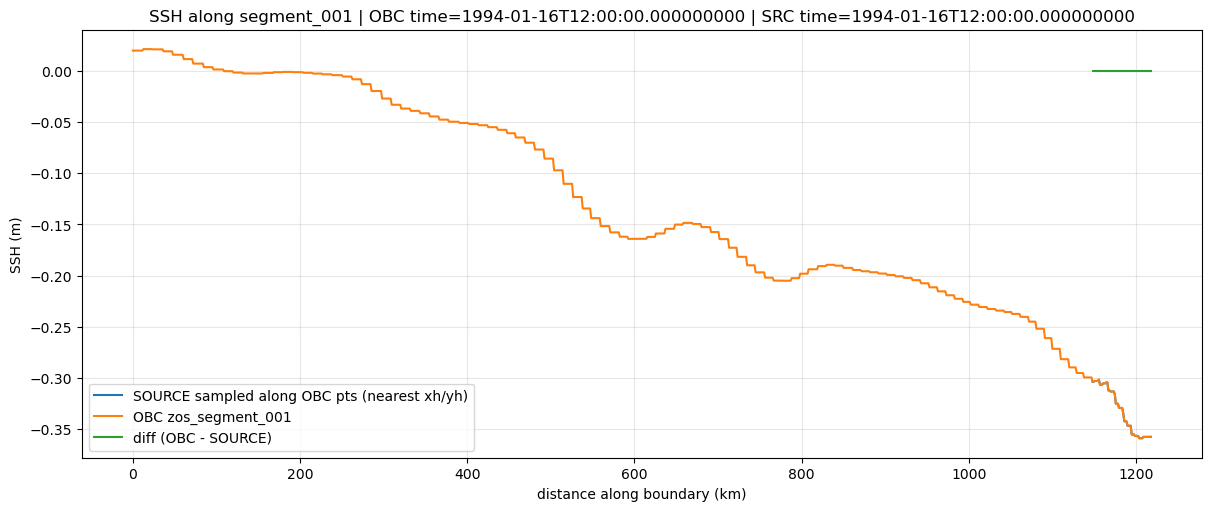


=== STATS (OBC - SOURCE) ===
finite points: 56 / 961
  mean: 0.0
  std : 0.0
  min : 0.0
  max : 0.0


In [14]:
#!/usr/bin/env python3
"""
Compare SSH along the OBC segment_001 transect:

1) Read your OBC SSH file -> lon_segment_001, lat_segment_001, zos_segment_001
2) Read the original/source SSH file (NEP) -> zos(time, yh, xh) with xh/yh (1D)
3) Sample the source field along the SAME (lon,lat) points using nearest neighbors in xh/yh
   (careful: we match lon convention of the source grid, and lat uses yh)

Outputs:
- 1D plot: OBC vs Source-sampled along-distance
- Prints min/max ranges and #points outside source bbox

This is intentionally SIMPLE and robust for your NEP files.
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# =========================
# EDIT THESE
# =========================
time_index = 0
obc_file = "./outputs_CGOA_feb26/zos_001_1994.nc"
src_file = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/19940101crpt_forc/ocean_month.nc"
seg = "001"

# =========================
# Helpers
# =========================
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_180_to_360(lon):
    lon = np.asarray(lon)
    return lon % 360

def lon_360_to_180(lon):
    lon = np.asarray(lon)
    return ((lon + 180) % 360) - 180

def is_0_360(lon):
    lon = np.asarray(lon)
    return (np.nanmin(lon) >= 0) and (np.nanmax(lon) > 180)

def nearest_1d_index_sorted(grid_1d_sorted, values):
    grid = np.asarray(grid_1d_sorted)
    v = np.asarray(values)
    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)
    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    return (idx - 1) + choose_right.astype(int)

def haversine_km(lon, lat):
    R = 6371.0
    lonr = np.deg2rad(np.asarray(lon))
    latr = np.deg2rad(np.asarray(lat))
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate([[0], np.cumsum(d)])

# =========================
# 1) Open OBC
# =========================
ds_o = xr.open_dataset(obc_file, decode_times=True)

zos_name = _find_var(ds_o, [f"zos_segment_{seg}", "zos_segment_001", "zos", "ssh"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

if any(v is None for v in [zos_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in OBC file. Vars: {list(ds_o.variables)}")

zos_obc = ds_o[zos_name].isel(time=time_index).squeeze(drop=True).values
lon_obc = ds_o[lon_name].squeeze(drop=True).values
lat_obc = ds_o[lat_name].squeeze(drop=True).values

# flatten
zos_obc = np.asarray(zos_obc).reshape(-1)
lon_obc = np.asarray(lon_obc).reshape(-1)
lat_obc = np.asarray(lat_obc).reshape(-1)

t_obc = ds_o["time"].isel(time=time_index).values if "time" in ds_o else None

# =========================
# 2) Open SOURCE
# =========================
ds_s = xr.open_dataset(src_file, decode_times=True)

src_zos_name = _find_var(ds_s, ["zos", "ssh"])
xh_name = _find_var(ds_s, ["xh", "lon", "longitude"])
yh_name = _find_var(ds_s, ["yh", "lat", "latitude"])

if src_zos_name is None:
    raise ValueError(f"Missing zos/ssh in source. data_vars={list(ds_s.data_vars)}")
if xh_name is None or yh_name is None:
    raise ValueError(f"Missing xh/yh in source. coords={list(ds_s.coords)} vars={list(ds_s.variables)}")

src = ds_s[src_zos_name].isel(time=time_index)
xh = ds_s[xh_name].values
yh = ds_s[yh_name].values

src_vals = src.values
if src_vals.ndim != 2:
    raise ValueError(f"Expected 2D source field after isel(time). Got {src_vals.shape} dims={src.dims}")

t_src = ds_s["time"].isel(time=time_index).values if "time" in ds_s else None

# =========================
# 3) Make lon conventions match SOURCE
# (THIS is the main gotcha)
# =========================
if is_0_360(xh):
    lon_obc_use = lon_180_to_360(lon_obc)
    xh_use = xh
else:
    lon_obc_use = lon_360_to_180(lon_obc)
    xh_use = xh

# Also ensure xh/yh are sorted increasing for searchsorted
# (yh almost always is; xh should be, but enforce)
xh_order = np.argsort(xh_use)
xh_s = xh_use[xh_order]
src_vals_s = src_vals[:, xh_order]

yh_order = np.argsort(yh)
yh_s = yh[yh_order]
src_vals_s2 = src_vals_s[yh_order, :]

# bbox coverage
in_lon = (lon_obc_use >= np.nanmin(xh_s)) & (lon_obc_use <= np.nanmax(xh_s))
in_lat = (lat_obc >= np.nanmin(yh_s)) & (lat_obc <= np.nanmax(yh_s))
in_box = in_lon & in_lat

print("=== RANGE CHECK ===")
print("Source lon min/max:", float(np.nanmin(xh_s)), float(np.nanmax(xh_s)))
print("Source lat min/max:", float(np.nanmin(yh_s)), float(np.nanmax(yh_s)))
print("OBC lon  min/max (matched):", float(np.nanmin(lon_obc_use)), float(np.nanmax(lon_obc_use)))
print("OBC lat  min/max:", float(np.nanmin(lat_obc)), float(np.nanmax(lat_obc)))
print("Points inside source bbox:", int(in_box.sum()), "/", int(in_box.size))
print("===================")

# nearest sample source at OBC points
src_at_obc = np.full_like(zos_obc, np.nan, dtype=float)

ix = nearest_1d_index_sorted(xh_s, lon_obc_use[in_box])
iy = nearest_1d_index_sorted(yh_s, lat_obc[in_box])

src_at_obc[in_box] = src_vals_s2[iy, ix]

# distance axis along transect (use original lon/lat for geometry)
s_km = haversine_km(lon_obc, lat_obc)

# =========================
# 4) Plot
# =========================
fig, ax = plt.subplots(1, 1, figsize=(12, 5), constrained_layout=True)
ax.plot(s_km, src_at_obc, label="SOURCE sampled along OBC pts (nearest xh/yh)")
ax.plot(s_km, zos_obc,    label="OBC zos_segment_001")
ax.plot(s_km, zos_obc - src_at_obc, label="diff (OBC - SOURCE)")
ax.set_title(f"SSH along segment_{seg} | OBC time={t_obc} | SRC time={t_src}")
ax.set_xlabel("distance along boundary (km)")
ax.set_ylabel("SSH (m)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

# stats
diff = zos_obc - src_at_obc
finite = np.isfinite(diff)
print("\n=== STATS (OBC - SOURCE) ===")
print("finite points:", int(finite.sum()), "/", int(diff.size))
if finite.any():
    print("  mean:", float(np.nanmean(diff)))
    print("  std :", float(np.nanstd(diff)))
    print("  min :", float(np.nanmin(diff)))
    print("  max :", float(np.nanmax(diff)))

/vftmp/Remi.Pages/pid218228/ipykernel_218434/1139819023.py:76: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_n = xr.open_dataset(nep_file, decode_times=True)


NEP xh min/max (raw): 229.14501953125 254.96383666992188
NEP xh min/max (-180..180): -130.85498046875 -105.03616333007812
NEP yh min/max: 13.861797332763672 59.5235710144043
NEP field shape: (816, 342)
OBC lon min/max: -144.30001831054688 -129.9105682373047
OBC lon min/max (-180..180): -144.30001831054688 -129.9105682373047
OBC lat min/max: 48.423954010009766 54.81351089477539


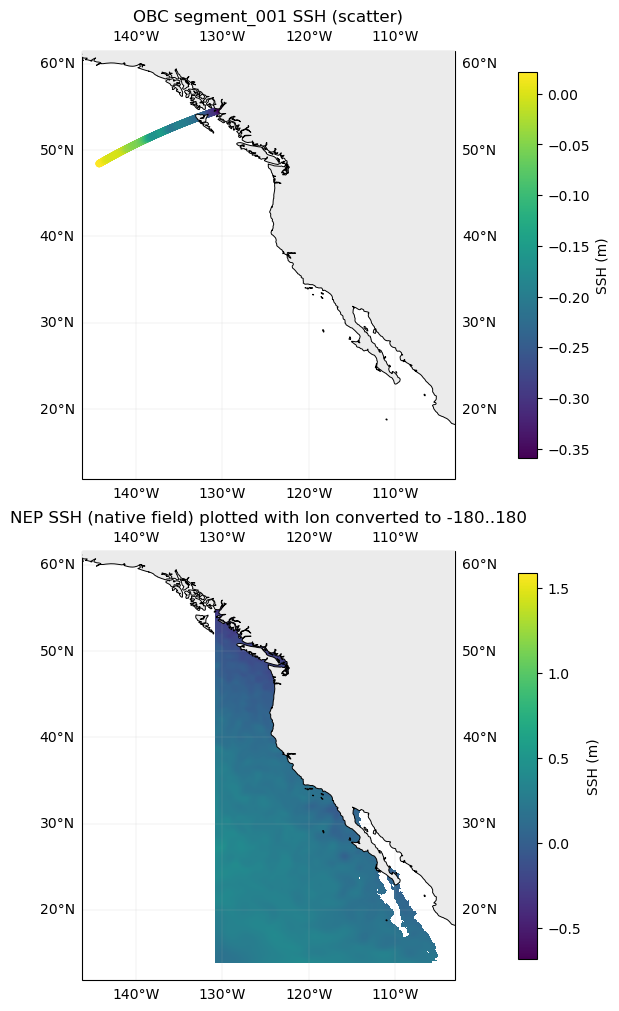

Transect points inside NEP bbox: 56 / 961


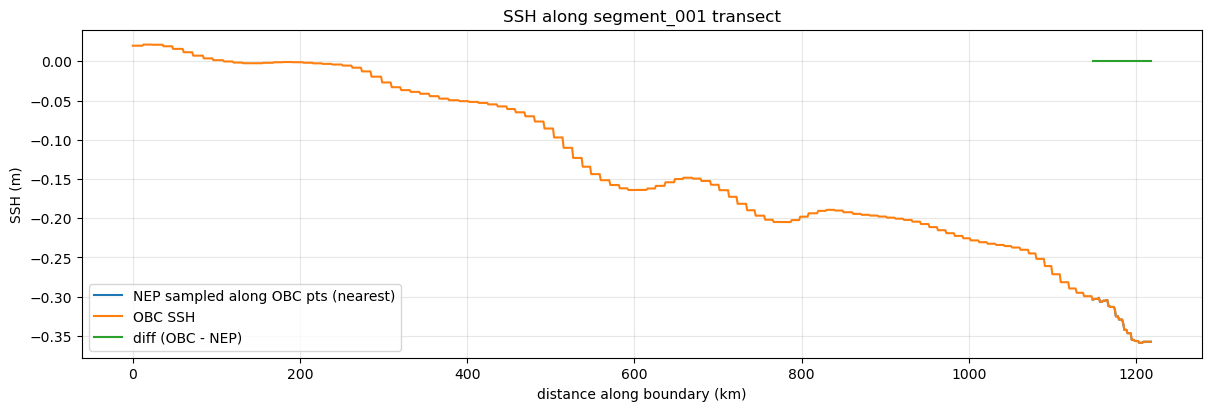

In [16]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -------------------------
# EDIT
# -------------------------
time_index = 0
seg = "001"

obc_file = "./outputs_CGOA_feb26/zos_001_1994.nc"
nep_file = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/19940101crpt_forc/ocean_month.nc"

# -------------------------
# helpers
# -------------------------
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon360_to_lon180(lon):
    lon = np.asarray(lon)
    return ((lon + 180) % 360) - 180

def nearest_1d_index_sorted(grid_sorted, values):
    grid = np.asarray(grid_sorted)
    v = np.asarray(values)
    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)
    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    return (idx - 1) + choose_right.astype(int)

def haversine_km(lon, lat):
    R = 6371.0
    lonr = np.deg2rad(np.asarray(lon))
    latr = np.deg2rad(np.asarray(lat))
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
    d = 2*R*np.arcsin(np.sqrt(a))
    return np.concatenate([[0], np.cumsum(d)])

def add_map(ax):
    ax.add_feature(cfeature.LAND, zorder=10, facecolor="0.92")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=11)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4, xlocs=None, ylocs=None)

# -------------------------
# open OBC
# -------------------------
ds_o = xr.open_dataset(obc_file, decode_times=True)
zos_name = _find_var(ds_o, [f"zos_segment_{seg}", "zos_segment_001", "zos", "ssh"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

if any(v is None for v in [zos_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in OBC file. Vars={list(ds_o.variables)}")

zos_obc = ds_o[zos_name].isel(time=time_index).squeeze(drop=True).values.reshape(-1)
lon_obc = ds_o[lon_name].squeeze(drop=True).values.reshape(-1)
lat_obc = ds_o[lat_name].squeeze(drop=True).values.reshape(-1)

# OBC lon for plotting in -180..180
lon_obc_180 = lon360_to_lon180(lon_obc)

# -------------------------
# open NEP
# -------------------------
ds_n = xr.open_dataset(nep_file, decode_times=True)
nep_zos_name = _find_var(ds_n, ["zos", "ssh"])
xh_name = _find_var(ds_n, ["xh", "lon", "longitude"])
yh_name = _find_var(ds_n, ["yh", "lat", "latitude"])

if nep_zos_name is None or xh_name is None or yh_name is None:
    raise ValueError(f"Missing vars in NEP file. data_vars={list(ds_n.data_vars)} coords={list(ds_n.coords)}")

nep = ds_n[nep_zos_name].isel(time=time_index)
xh = ds_n[xh_name].values          # likely 0..360
yh = ds_n[yh_name].values
nep_vals = nep.values              # (yh, xh)

if nep_vals.ndim != 2:
    raise ValueError(f"Expected 2D NEP field after isel(time). Got {nep_vals.shape}, dims={nep.dims}")

# Convert NEP lon for plotting to -180..180 WITHOUT sorting/reordering
xh_180 = lon360_to_lon180(xh)

# -------------------------
# sanity prints (will tell you instantly if something is weird)
# -------------------------
print("NEP xh min/max (raw):", float(np.nanmin(xh)), float(np.nanmax(xh)))
print("NEP xh min/max (-180..180):", float(np.nanmin(xh_180)), float(np.nanmax(xh_180)))
print("NEP yh min/max:", float(np.nanmin(yh)), float(np.nanmax(yh)))
print("NEP field shape:", nep_vals.shape)

print("OBC lon min/max:", float(np.nanmin(lon_obc)), float(np.nanmax(lon_obc)))
print("OBC lon min/max (-180..180):", float(np.nanmin(lon_obc_180)), float(np.nanmax(lon_obc_180)))
print("OBC lat min/max:", float(np.nanmin(lat_obc)), float(np.nanmax(lat_obc)))

# -------------------------
# MAP PLOTS
# -------------------------
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1])

# extent around BOTH (in -180..180)
lon_min = min(np.nanmin(xh_180), np.nanmin(lon_obc_180)) - 2
lon_max = max(np.nanmax(xh_180), np.nanmax(lon_obc_180)) + 2
lat_min = min(np.nanmin(yh), np.nanmin(lat_obc)) - 2
lat_max = max(np.nanmax(yh), np.nanmax(lat_obc)) + 2

# top: OBC scatter
ax0 = fig.add_subplot(gs[0, 0], projection=proj)
ax0.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
add_map(ax0)
sc = ax0.scatter(lon_obc_180, lat_obc, c=zos_obc, s=18, transform=proj)
ax0.set_title("OBC segment_001 SSH (scatter)")
cb0 = plt.colorbar(sc, ax=ax0, shrink=0.9, pad=0.02)
cb0.set_label("SSH (m)")

# bottom: NEP field (native data, plotted in -180..180)
ax1 = fig.add_subplot(gs[1, 0], projection=proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
add_map(ax1)
pm = ax1.pcolormesh(xh_180, yh, nep_vals, shading="nearest", transform=proj)
ax1.set_title("NEP SSH (native field) plotted with lon converted to -180..180")
cb1 = plt.colorbar(pm, ax=ax1, shrink=0.9, pad=0.02)
cb1.set_label("SSH (m)")

plt.show()

# -------------------------
# TRANSECT: sample NEP along OBC lon/lat
# -------------------------
# For sampling, also use lon in same coordinates as xh_180
# xh_180 should already be monotonic for your domain (229..255 -> -131..-105)
# If not monotonic, THEN we sort and reorder nep_vals consistently.
if np.any(np.diff(xh_180) < 0):
    order = np.argsort(xh_180)
    xh_180_s = xh_180[order]
    nep_vals_s = nep_vals[:, order]
else:
    xh_180_s = xh_180
    nep_vals_s = nep_vals

# Ensure yh increasing
if np.any(np.diff(yh) < 0):
    ordery = np.argsort(yh)
    yh_s = yh[ordery]
    nep_vals_s = nep_vals_s[ordery, :]
else:
    yh_s = yh

# bbox check
in_lon = (lon_obc_180 >= np.nanmin(xh_180_s)) & (lon_obc_180 <= np.nanmax(xh_180_s))
in_lat = (lat_obc >= np.nanmin(yh_s)) & (lat_obc <= np.nanmax(yh_s))
in_box = in_lon & in_lat
print("Transect points inside NEP bbox:", int(in_box.sum()), "/", int(in_box.size))

nep_at_obc = np.full_like(zos_obc, np.nan, dtype=float)
ix = nearest_1d_index_sorted(xh_180_s, lon_obc_180[in_box])
iy = nearest_1d_index_sorted(yh_s, lat_obc[in_box])
nep_at_obc[in_box] = nep_vals_s[iy, ix]

s_km = haversine_km(lon_obc, lat_obc)

plt.figure(figsize=(12, 4), constrained_layout=True)
plt.plot(s_km, nep_at_obc, label="NEP sampled along OBC pts (nearest)")
plt.plot(s_km, zos_obc, label="OBC SSH")
plt.plot(s_km, zos_obc - nep_at_obc, label="diff (OBC - NEP)")
plt.grid(True, alpha=0.3)
plt.xlabel("distance along boundary (km)")
plt.ylabel("SSH (m)")
plt.title("SSH along segment_001 transect")
plt.legend()
plt.show()

In [17]:
print(ds_n[nep_zos_name].dims)
print(ds_n[xh_name].attrs, ds_n[yh_name].attrs)
print("xh head/tail:", xh[:5], xh[-5:])
print("yh head/tail:", yh[:5], yh[-5:])

('time', 'yh', 'xh')
{'units': 'degrees_east', 'long_name': 'h point nominal longitude', 'axis': 'X'} {'units': 'degrees_north', 'long_name': 'h point nominal latitude', 'axis': 'Y'}
xh head/tail: [229.14501953 229.21002197 229.27508545 229.34022522 229.40542603] [254.62509155 254.7097168  254.79437256 254.87908936 254.96383667]
yh head/tail: [13.86179733 13.93039322 13.99901676 14.06766891 14.13635063] [59.49391174 59.50164413 59.50916672 59.51647568 59.52357101]


/vftmp/Remi.Pages/pid218228/ipykernel_218434/1700548081.py:39: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_n = xr.open_dataset(nep_file, decode_times=True)


NEP lon range: -130.85498046875 -105.03616333007812
OBC lon range: -144.30001831054688 -129.9105682373047
OBC points inside NEP bbox: 56 / 961


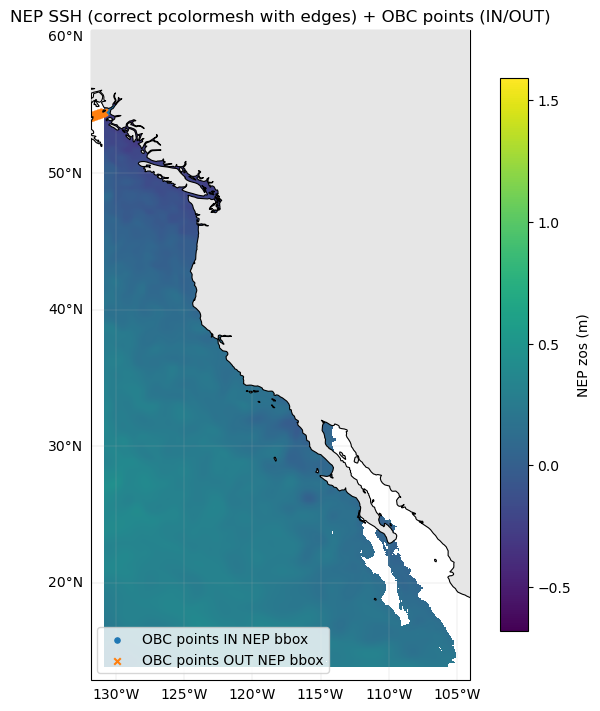

In [18]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

time_index = 0
obc_file = "./outputs_CGOA_feb26/zos_001_1994.nc"
nep_file = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/19940101crpt_forc/ocean_month.nc"

def lon360_to_lon180(lon):
    lon = np.asarray(lon)
    return ((lon + 180) % 360) - 180

def edges_from_centers_1d(c):
    """Return (N+1) edges for N centers, assuming monotonic spacing."""
    c = np.asarray(c)
    dc = np.diff(c)
    e = np.empty(c.size + 1, dtype=float)
    e[1:-1] = c[:-1] + 0.5 * dc
    e[0] = c[0] - 0.5 * dc[0]
    e[-1] = c[-1] + 0.5 * dc[-1]
    return e

def add_map(ax):
    ax.add_feature(cfeature.LAND, facecolor="0.9", zorder=10)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

# ---- OBC ----
ds_o = xr.open_dataset(obc_file, decode_times=True)
lon_o = ds_o["lon_segment_001"].values.reshape(-1)
lat_o = ds_o["lat_segment_001"].values.reshape(-1)
zos_o = ds_o["zos_segment_001"].isel(time=time_index).values.reshape(-1)

# ---- NEP ----
ds_n = xr.open_dataset(nep_file, decode_times=True)
zos_n = ds_n["zos"].isel(time=time_index).values  # (yh,xh)
xh = ds_n["xh"].values
yh = ds_n["yh"].values

# Convert NEP lon to -180..180 (monotonic here)
xh180 = lon360_to_lon180(xh)

# Build edges for pcolormesh (fix coastline “shift” look)
xh_e = edges_from_centers_1d(xh180)
yh_e = edges_from_centers_1d(yh)

# Domain check for OBC points relative to NEP
in_lon = (lon_o >= xh180.min()) & (lon_o <= xh180.max())
in_lat = (lat_o >= yh.min()) & (lat_o <= yh.max())
in_domain = in_lon & in_lat

print("NEP lon range:", float(xh180.min()), float(xh180.max()))
print("OBC lon range:", float(lon_o.min()), float(lon_o.max()))
print("OBC points inside NEP bbox:", int(in_domain.sum()), "/", int(in_domain.size))

# ---- Plot NEP with correct edges ----
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=proj)
add_map(ax)

# Set extent to NEP domain ONLY (so you don't think it's "cut")
ax.set_extent([float(xh180.min())-1, float(xh180.max())+1,
               float(yh.min())-1, float(yh.max())+1], crs=proj)

pm = ax.pcolormesh(xh_e, yh_e, zos_n, shading="auto", transform=proj)
plt.colorbar(pm, ax=ax, shrink=0.85, pad=0.02, label="NEP zos (m)")

# Overlay OBC points (IN green, OUT red)
ax.scatter(lon_o[in_domain],  lat_o[in_domain],  s=14, marker="o",
           transform=proj, label="OBC points IN NEP bbox")
ax.scatter(lon_o[~in_domain], lat_o[~in_domain], s=22, marker="x",
           transform=proj, label="OBC points OUT NEP bbox")

ax.set_title("NEP SSH (correct pcolormesh with edges) + OBC points (IN/OUT)")
ax.legend(loc="lower left")
plt.show()

/vftmp/Remi.Pages/pid218228/ipykernel_218434/1974490741.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(nep_file, decode_times=True)


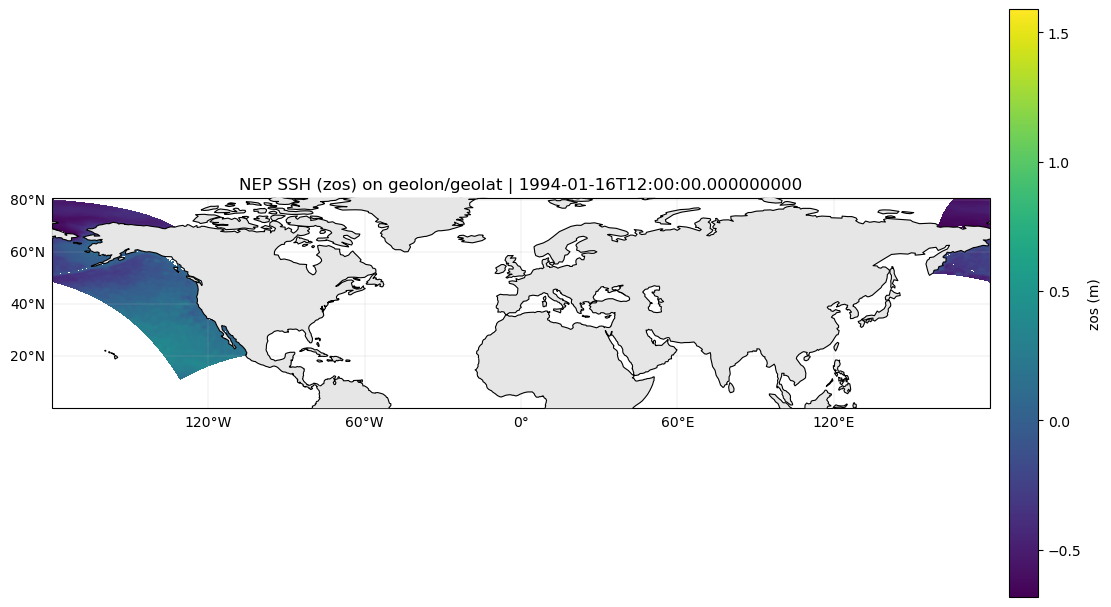

In [24]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

time_index = 0
nep_file   = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/19940101crpt_forc/ocean_month.nc"
static_file = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/19940101crpt_forc/ocean_static.nc"  # EDIT if needed

ds = xr.open_dataset(nep_file, decode_times=True)
st = xr.open_dataset(static_file, decode_times=False)

zos = ds["zos"].isel(time=time_index).values                 # (yh,xh)
lon = np.nan_to_num(st["geolon"].values  )                                 # (yh,xh)
lat = np.nan_to_num(st["geolat"].values  )                                 # (yh,xh)
t = ds["time"].isel(time=time_index).values if "time" in ds else None

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=proj)

ax.add_feature(cfeature.LAND, facecolor="0.9", zorder=10)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# NOTE: pcolormesh supports 2D lon/lat
pm = ax.pcolormesh(lon, lat, zos, shading="auto", transform=proj)
cb = plt.colorbar(pm, ax=ax, shrink=0.85, pad=0.02)
cb.set_label("zos (m)")

ax.set_title(f"NEP SSH (zos) on geolon/geolat | {str(t)}" if t is not None else "NEP SSH (zos) on geolon/geolat")
plt.show()

In [21]:
lon.shape

(816, 342)

In [22]:
zos.shape

(816, 342)

In [23]:
lat.shape

(816, 342)

/vftmp/Remi.Pages/pid218228/ipykernel_218434/1360032488.py:97: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_m = xr.open_dataset(nep_month_file, decode_times=True)


unique sampled cells: 221


/vftmp/Remi.Pages/pid218228/ipykernel_218434/1360032488.py:144: UserWarning: Adding colorbar to a different Figure <Figure size 1100x700 with 2 Axes> than <Figure size 1200x1200 with 5 Axes> which fig.colorbar is called on.
  cb1 = plt.colorbar(pm, ax=ax1, shrink=0.85, pad=0.02)


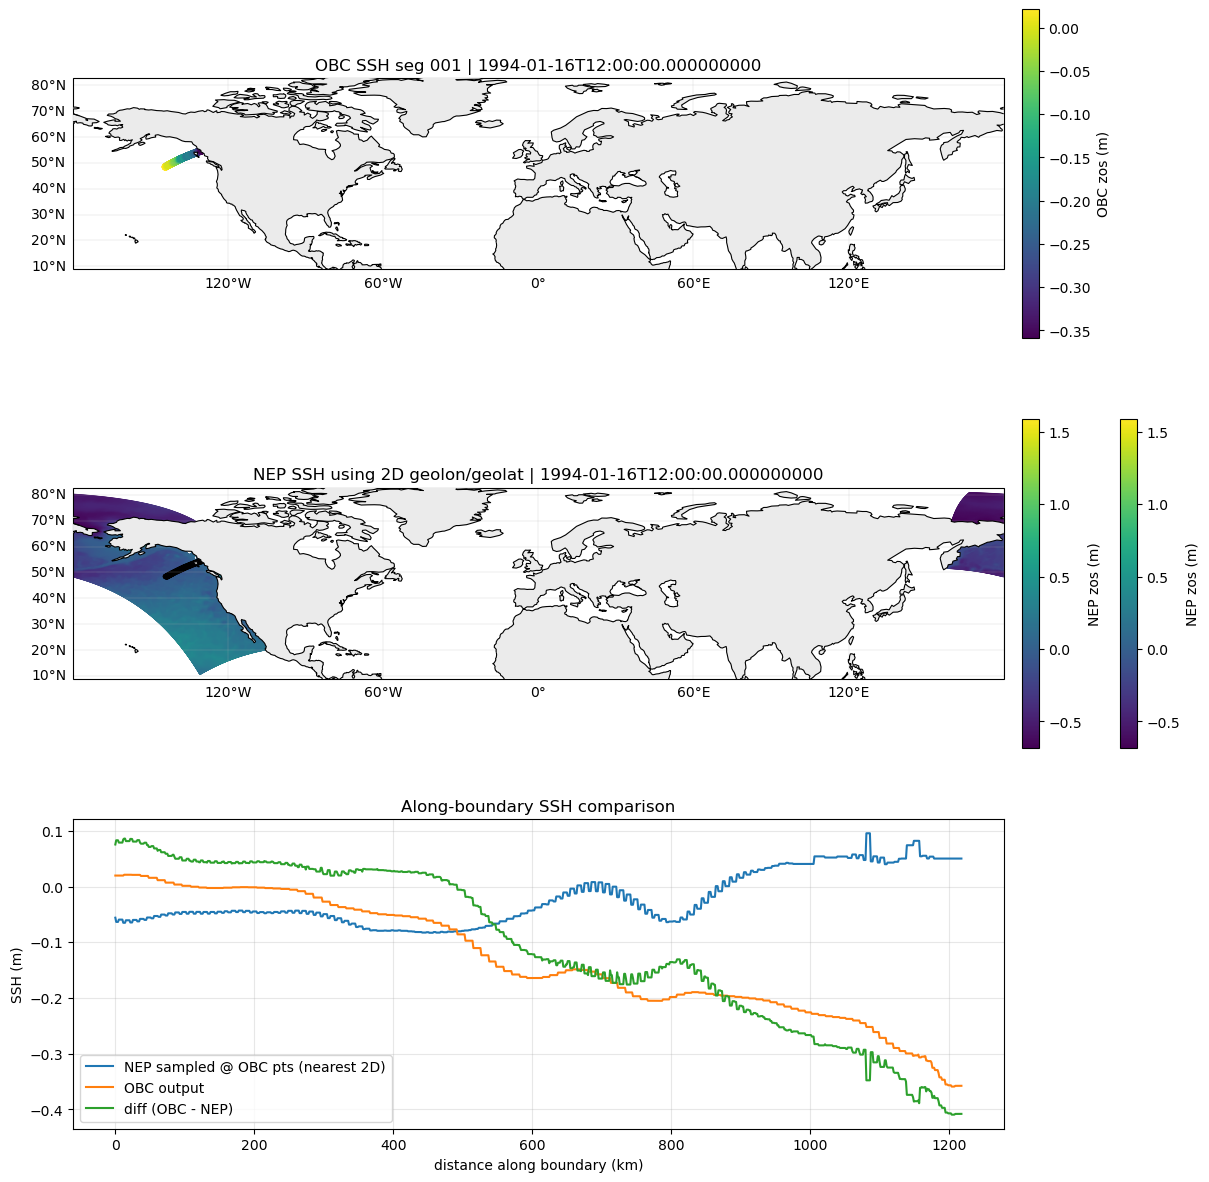

Stats (OBC - NEP sampled):
  mean: -0.10830400139093399
  std : 0.14539293944835663
  min : -0.409423828125
  max : 0.08625127375125885


In [32]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ===== EDIT =====
year = 1994
time_index = 0
seg = "001"

obc_file = f"./outputs_CGOA_feb26_1D/zos_{int(seg):03d}_{year}.nc"
nep_month_file = f"/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/{year}0101crpt_forc/ocean_month.nc"
nep_static_file = "/archive/Liz.Drenkard/fre/cefi/NEP/2025_07/NEP10k_202507_physics_bgc/gfdl.ncrc6-intel23-repro/pp/ocean_daily/ocean_daily.static.nc"

# ===== helpers =====
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def add_map(ax):
    ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=10)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

def haversine_km(lon, lat):
    R = 6371.0
    lonr = np.deg2rad(np.asarray(lon))
    latr = np.deg2rad(np.asarray(lat))
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate([[0], np.cumsum(d)])

def lon_180_to_360(lon):
    lon = np.asarray(lon)
    return lon % 360

def nearest_2d_indices_valid_periodic(lon2d, lat2d, field2d, lon_pts, lat_pts, chunk=400):
    lon2d = np.asarray(lon2d)
    lat2d = np.asarray(lat2d)
    field2d = np.asarray(field2d)

    # Convert BOTH source and target to 0..360 for consistency
    lon2d_360 = lon_180_to_360(lon2d)
    lon_pts_360 = lon_180_to_360(lon_pts)

    valid = np.isfinite(lon2d_360) & np.isfinite(lat2d) & np.isfinite(field2d)
    if valid.sum() == 0:
        raise ValueError("No valid points found in source.")

    lonf = lon2d_360[valid].ravel()
    latf = lat2d[valid].ravel()
    valid_flat = np.flatnonzero(valid.ravel())

    lon_pts_360 = np.asarray(lon_pts_360).ravel()
    lat_pts = np.asarray(lat_pts).ravel()
    out_compact = np.empty(lon_pts_360.size, dtype=np.int64)

    def dlon_periodic(a, b):
        d = np.abs(a - b)
        return np.minimum(d, 360.0 - d)

    for k0 in range(0, lon_pts_360.size, chunk):
        k1 = min(lon_pts_360.size, k0 + chunk)
        lp = lon_pts_360[k0:k1][:, None]
        ap = lat_pts[k0:k1][:, None]

        dlon = dlon_periodic(lonf[None, :], lp)
        dlat = (latf[None, :] - ap)
        d2 = dlon**2 + dlat**2

        out_compact[k0:k1] = np.argmin(d2, axis=1)

    flat_idx = valid_flat[out_compact]
    jj, ii = np.unravel_index(flat_idx, lon2d.shape)
    return jj, ii
# ===== open OBC =====
ds_o = xr.open_dataset(obc_file, decode_times=True)
zos_name = _find_var(ds_o, [f"zos_segment_{seg}", "zos_segment_001", "zos"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])
if any(v is None for v in [zos_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in {obc_file}. Vars={list(ds_o.variables)}")

zos_o = ds_o[zos_name].isel(time=time_index).squeeze(drop=True).values.reshape(-1)
lon_o = ds_o[lon_name].values.reshape(-1)
lat_o = ds_o[lat_name].values.reshape(-1)
t_obc = ds_o["time"].isel(time=time_index).values if "time" in ds_o else None

# ===== open NEP (zos + static geolon/geolat) =====
ds_m = xr.open_dataset(nep_month_file, decode_times=True)
ds_s = xr.open_dataset(nep_static_file, decode_times=False)

zos_m = ds_m["zos"].isel(time=time_index).values
t_src = ds_m["time"].isel(time=time_index).values if "time" in ds_m else None

lonT = ds_s["geolon"].values
latT = ds_s["geolat"].values

# sample NEP at OBC points using nearest in 2D (debug)
jj, ii = nearest_2d_indices_valid_periodic(lonT, latT, zos_m, lon_o, lat_o)
zos_nep_at_obc = zos_m[jj, ii]
print("unique sampled cells:", np.unique(np.ravel_multi_index((jj, ii), lonT.shape)).size)

# distance along boundary
s_km = haversine_km(lon_o, lat_o)

# ===== plot maps =====
proj = ccrs.PlateCarree()
lon_min = min(np.nanmin(lon_o), np.nanmin(lonT)) - 2
lon_max = max(np.nanmax(lon_o), np.nanmax(lonT)) + 2
lat_min = min(np.nanmin(lat_o), np.nanmin(latT)) - 2
lat_max = max(np.nanmax(lat_o), np.nanmax(latT)) + 2

fig = plt.figure(figsize=(12, 12), constrained_layout=True)
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.8])

ax0 = fig.add_subplot(gs[0, 0], projection=proj)
ax0.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
add_map(ax0)
sc = ax0.scatter(lon_o, lat_o, c=zos_o, s=18, transform=proj)
ax0.set_title(f"OBC SSH seg {seg} | {t_obc}")
cb0 = plt.colorbar(sc, ax=ax0, shrink=0.85, pad=0.02)
cb0.set_label("OBC zos (m)")

ax1 = fig.add_subplot(gs[1, 0], projection=proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
add_map(ax1)

mask = np.isfinite(lonT) & np.isfinite(latT) & np.isfinite(zos_m)
sc2 = ax1.scatter(lonT[mask], latT[mask], c=zos_m[mask],
                  s=1, marker=".", transform=proj)
cb1 = plt.colorbar(sc2, ax=ax1, shrink=0.85, pad=0.02)
cb1.set_label("NEP zos (m)")

ax1.scatter(lon_o, lat_o, s=8, color="k", alpha=0.6, transform=proj)
ax1.set_title(f"NEP SSH using 2D geolon/geolat | {t_src}")
cb1 = plt.colorbar(pm, ax=ax1, shrink=0.85, pad=0.02)
cb1.set_label("NEP zos (m)")

ax2 = fig.add_subplot(gs[2, 0])
ax2.plot(s_km, zos_nep_at_obc, label="NEP sampled @ OBC pts (nearest 2D)")
ax2.plot(s_km, zos_o,          label="OBC output")
ax2.plot(s_km, zos_o - zos_nep_at_obc, label="diff (OBC - NEP)")
ax2.set_title("Along-boundary SSH comparison")
ax2.set_xlabel("distance along boundary (km)")
ax2.set_ylabel("SSH (m)")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="best")

plt.show()

diff = zos_o - zos_nep_at_obc
print("Stats (OBC - NEP sampled):")
print("  mean:", float(np.nanmean(diff)))
print("  std :", float(np.nanstd(diff)))
print("  min :", float(np.nanmin(diff)))
print("  max :", float(np.nanmax(diff)))

In [33]:
print("OBC lon range (-180..180):", float(np.nanmin(lon_o)), float(np.nanmax(lon_o)))
print("OBC lon range (0..360):", float(np.nanmin(lon_o % 360)), float(np.nanmax(lon_o % 360)))
print("NEP lon range raw:", float(np.nanmin(lonT[np.isfinite(lonT)])), float(np.nanmax(lonT[np.isfinite(lonT)])))

OBC lon range (-180..180): -144.30001831054688 -129.9105682373047
OBC lon range (0..360): 215.69998168945312 230.0894317626953
NEP lon range raw: 156.9248046875 254.971923828125


/vftmp/Remi.Pages/pid218228/ipykernel_218434/1860177948.py:42: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_m = xr.open_dataset(nep_month_file, decode_times=True)


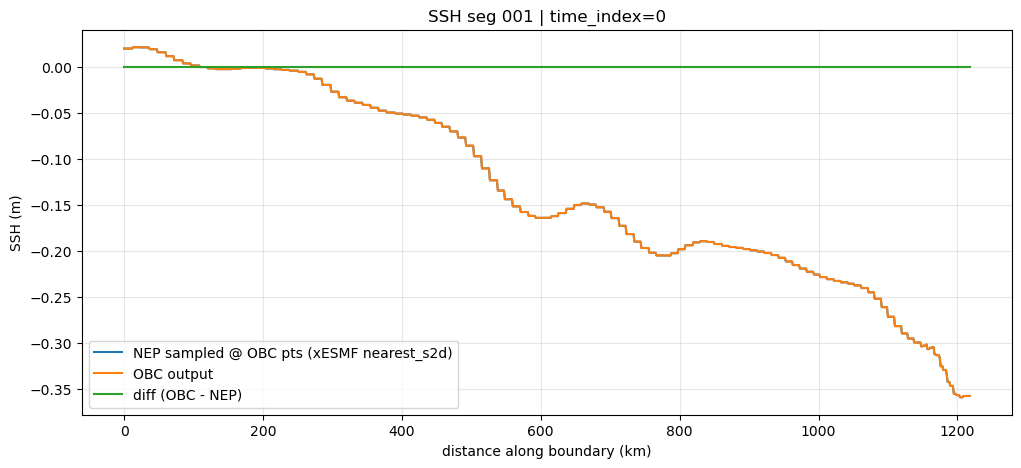

Stats (OBC - NEP xESMF sampled):
  finite: 961 / 961
  mean: 0.0
  std : 0.0
  min : 0.0
  max : 0.0


In [34]:
import numpy as np
import xarray as xr
import xesmf as xe
import matplotlib.pyplot as plt

year = 1994
time_index = 0
seg = "001"

obc_file = f"./outputs_CGOA_feb26_1D/zos_{int(seg):03d}_{year}.nc"
nep_month_file = f"/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/{year}0101crpt_forc/ocean_month.nc"

def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def haversine_km(lon, lat):
    R = 6371.0
    lonr = np.deg2rad(np.asarray(lon))
    latr = np.deg2rad(np.asarray(lat))
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate([[0], np.cumsum(d)])

# --- open OBC ---
ds_o = xr.open_dataset(obc_file, decode_times=True)
zos_name = _find_var(ds_o, [f"zos_segment_{seg}", "zos_segment_001", "zos"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])
if any(v is None for v in [zos_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in {obc_file}. Vars={list(ds_o.variables)}")

zos_o = ds_o[zos_name].isel(time=time_index).squeeze(drop=True).values.reshape(-1)
lon_o = ds_o[lon_name].values.reshape(-1)
lat_o = ds_o[lat_name].values.reshape(-1)

# --- open NEP zos on its native grid (1D xh/yh) ---
ds_m = xr.open_dataset(nep_month_file, decode_times=True)
zos_m = ds_m["zos"].isel(time=time_index)  # dims (yh,xh)
xh = ds_m["xh"]
yh = ds_m["yh"]

# Build source grid dataset for xESMF (rectilinear)
src = xr.Dataset({"lon": xh, "lat": yh})

# Build target LocStream dataset (OBC points)
tgt = xr.Dataset(
    {"lon": (("points",), lon_o),
     "lat": (("points",), lat_o)}
)

# xESMF regridder: nearest neighbor to points
regridder = xe.Regridder(src, tgt, method="nearest_s2d", locstream_out=True, periodic=True)

# Apply to NEP zos
zos_nep_at_obc = regridder(zos_m)

# Convert to 1D numpy
if isinstance(zos_nep_at_obc, xr.Dataset):
    # depending on xesmf version, might return Dataset
    zos_nep_at_obc = zos_nep_at_obc.to_array().squeeze()

zos_nep_at_obc = zos_nep_at_obc.values.reshape(-1)

# distance along boundary
s_km = haversine_km(lon_o, lat_o)

# Plot comparison
plt.figure(figsize=(12,5))
plt.plot(s_km, zos_nep_at_obc, label="NEP sampled @ OBC pts (xESMF nearest_s2d)")
plt.plot(s_km, zos_o, label="OBC output")
plt.plot(s_km, zos_o - zos_nep_at_obc, label="diff (OBC - NEP)")
plt.grid(True, alpha=0.3)
plt.xlabel("distance along boundary (km)")
plt.ylabel("SSH (m)")
plt.title(f"SSH seg {seg} | time_index={time_index}")
plt.legend()
plt.show()

diff = zos_o - zos_nep_at_obc
print("Stats (OBC - NEP xESMF sampled):")
print("  finite:", np.isfinite(diff).sum(), "/", diff.size)
print("  mean:", float(np.nanmean(diff)))
print("  std :", float(np.nanstd(diff)))
print("  min :", float(np.nanmin(diff)))
print("  max :", float(np.nanmax(diff)))

/vftmp/Remi.Pages/pid218228/ipykernel_218434/4174982192.py:60: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_m = xr.open_dataset(nep_month_file)


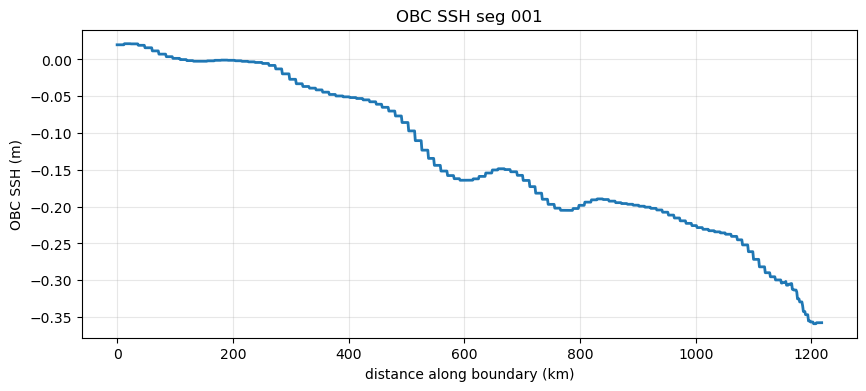

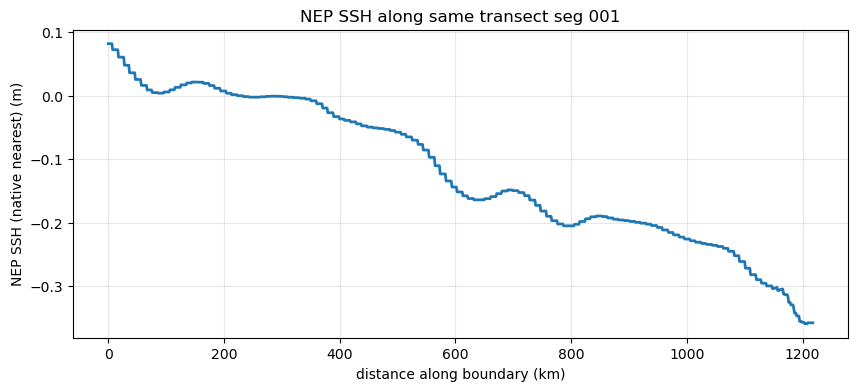

Stats (OBC - NEP native-nearest):
  mean: -0.01158189494162798
  std : 0.015585169196128845
  min : -0.06177492439746857
  max : 0.013869807124137878


In [56]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ===== EDIT =====
year = 1994
time_index = 0
seg = "001"

obc_file = f"./outputs_CGOA_feb26_1D/zos_{int(seg):03d}_{year}.nc"
nep_month_file = (
    f"/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/"
    f"NEPbgc_nudged_hindcast02/history/{year}0101crpt_forc/ocean_month.nc"
)

# ---------- helpers ----------
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_180_to_360(lon):
    lon = np.asarray(lon)
    return np.where(lon < 0, lon + 360.0, lon)

def haversine_km(lon, lat):
    R = 6371.0
    lonr = np.deg2rad(np.asarray(lon))
    latr = np.deg2rad(np.asarray(lat))
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate([[0], np.cumsum(d)])

def nearest_1d_index_sorted(grid, values):
    grid = np.asarray(grid)
    v = np.asarray(values)
    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)
    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    return (idx - 1) + choose_right.astype(int)

# ===== OPEN OBC =====
ds_o = xr.open_dataset(obc_file)
zos_name = _find_var(ds_o, [f"zos_segment_{seg}", "zos_segment_001", "zos"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

zos_o = ds_o[zos_name].isel(time=time_index).squeeze(drop=True).values.reshape(-1)
lon_o = ds_o[lon_name].values.reshape(-1)
lat_o = ds_o[lat_name].values.reshape(-1)

s_km = haversine_km(lon_o, lat_o)

# ===== OPEN NEP =====
ds_m = xr.open_dataset(nep_month_file)
zos_m = ds_m["zos"].isel(time=time_index)
xh = ds_m["xh"].values
yh = ds_m["yh"].values

# Match longitude convention
if np.nanmin(xh) >= 0:
    lon_for_nep = lon_180_to_360(lon_o)
else:
    lon_for_nep = lon_o

# Nearest native NEP grid indices
ix = nearest_1d_index_sorted(xh, lon_for_nep)
iy = nearest_1d_index_sorted(yh, lat_o)

nep_line = zos_m.values[iy, ix]

# ==========================
# Figure 1 – OBC only
# ==========================
plt.figure(figsize=(10,4))
plt.plot(s_km, zos_o, linewidth=2)
plt.xlabel("distance along boundary (km)")
plt.ylabel("OBC SSH (m)")
plt.title(f"OBC SSH seg {seg}")
plt.grid(True, alpha=0.3)
plt.show()

# ==========================
# Figure 2 – NEP native-nearest only
# ==========================
plt.figure(figsize=(10,4))
plt.plot(s_km, nep_line, linewidth=2)
plt.xlabel("distance along boundary (km)")
plt.ylabel("NEP SSH (native nearest) (m)")
plt.title(f"NEP SSH along same transect seg {seg}")
plt.grid(True, alpha=0.3)
plt.show()

# ==========================
# Optional: direct diff
# ==========================
diff = zos_o - nep_line
print("Stats (OBC - NEP native-nearest):")
print("  mean:", float(np.nanmean(diff)))
print("  std :", float(np.nanstd(diff)))
print("  min :", float(np.nanmin(diff)))
print("  max :", float(np.nanmax(diff)))

/vftmp/Remi.Pages/pid218228/ipykernel_218434/327888681.py:64: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_n = xr.open_dataset(nep_u_file, decode_times=True)


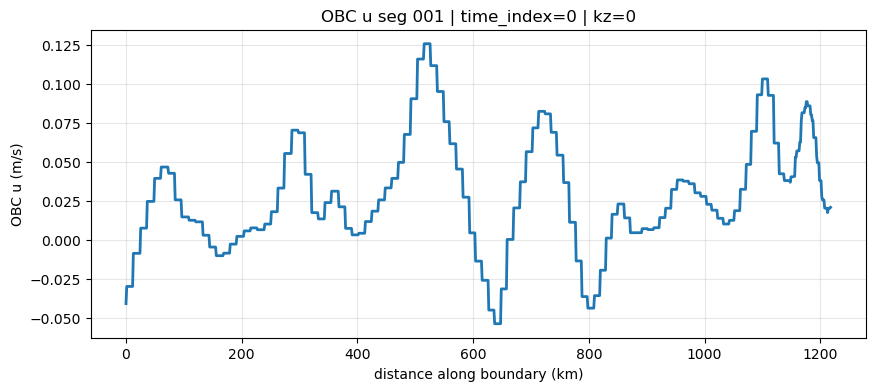

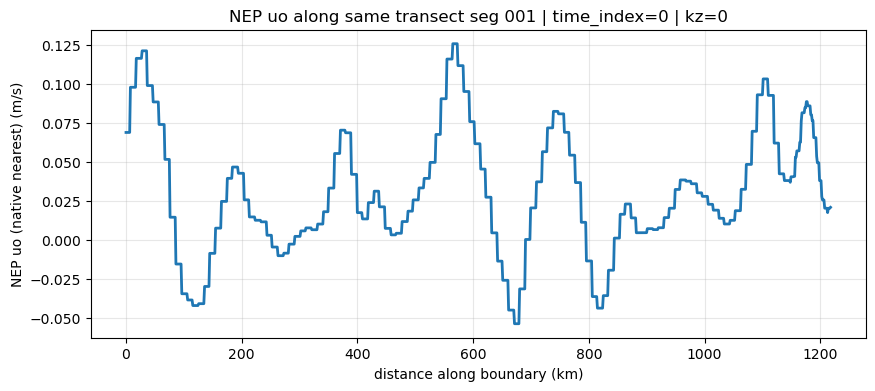

Stats (OBC u - NEP uo native-nearest):
  mean: -0.0017045889981091022
  std : 0.04154049605131149
  min : -0.12803485989570618
  max : 0.0905269905924797


In [40]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ===== EDIT =====
year = 1994
time_index = 0
seg = "001"
kz = 0  # surface index (change to -1 if your z is reversed)

uv_obc_file = f"./outputs_CGOA_feb26_1D/uv_{int(seg):03d}.nc"          # <- your concatenated uv_001.nc
nep_u_file   = f"/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/{year}0101crpt_forc/ocean_month_z.nc"

# ---------- helpers ----------
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_180_to_360(lon):
    lon = np.asarray(lon)
    return np.where(lon < 0, lon + 360.0, lon)

def haversine_km(lon, lat):
    R = 6371.0
    lonr = np.deg2rad(np.asarray(lon))
    latr = np.deg2rad(np.asarray(lat))
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate([[0], np.cumsum(d)])

def nearest_1d_index_sorted(grid, values):
    """grid must be 1D sorted ascending"""
    grid = np.asarray(grid)
    v = np.asarray(values)
    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)
    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    return (idx - 1) + choose_right.astype(int)

# ===== OPEN OBC uv =====
ds_o = xr.open_dataset(uv_obc_file, decode_times=True)

u_name   = _find_var(ds_o, [f"u_segment_{seg}", "u_segment_001", "u"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

if any(v is None for v in [u_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in {uv_obc_file}. Vars={list(ds_o.variables)}")

# OBC u at time, surface, boundary points
u_obc = ds_o[u_name].isel(time=time_index, nz_segment_001=kz).squeeze(drop=True).values.reshape(-1)
lon_o = ds_o[lon_name].values.reshape(-1)
lat_o = ds_o[lat_name].values.reshape(-1)

s_km = haversine_km(lon_o, lat_o)

# ===== OPEN NEP uo =====
ds_n = xr.open_dataset(nep_u_file, decode_times=True)
uo = ds_n["uo"].isel(time=time_index, z_l=kz) if "z_l" in ds_n["uo"].dims else ds_n["uo"].isel(time=time_index, z=kz)

# Identify NEP u-grid coordinates (likely xq and yh)
xq = ds_n["xq"].values
yh = ds_n["yh"].values

# Match lon convention
if np.nanmin(xq) >= 0 and np.nanmax(xq) > 180:
    lon_for_nep = lon_180_to_360(lon_o)
else:
    lon_for_nep = lon_o

# Nearest native indices for uo on (yh, xq)
ix = nearest_1d_index_sorted(xq, lon_for_nep)
iy = nearest_1d_index_sorted(yh, lat_o)

u_nep = uo.values[iy, ix]

# ==========================
# Figure 1 – OBC u only
# ==========================
plt.figure(figsize=(10,4))
plt.plot(s_km, u_obc, linewidth=2)
plt.xlabel("distance along boundary (km)")
plt.ylabel("OBC u (m/s)")
plt.title(f"OBC u seg {seg} | time_index={time_index} | kz={kz}")
plt.grid(True, alpha=0.3)
plt.show()

# ==========================
# Figure 2 – NEP uo native-nearest only
# ==========================
plt.figure(figsize=(10,4))
plt.plot(s_km, u_nep, linewidth=2)
plt.xlabel("distance along boundary (km)")
plt.ylabel("NEP uo (native nearest) (m/s)")
plt.title(f"NEP uo along same transect seg {seg} | time_index={time_index} | kz={kz}")
plt.grid(True, alpha=0.3)
plt.show()

# Optional stats
diff = u_obc - u_nep
print("Stats (OBC u - NEP uo native-nearest):")
print("  mean:", float(np.nanmean(diff)))
print("  std :", float(np.nanstd(diff)))
print("  min :", float(np.nanmin(diff)))
print("  max :", float(np.nanmax(diff)))

/vftmp/Remi.Pages/pid218228/ipykernel_218434/3311573409.py:74: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_n = xr.open_dataset(nep_uv_file, decode_times=True)


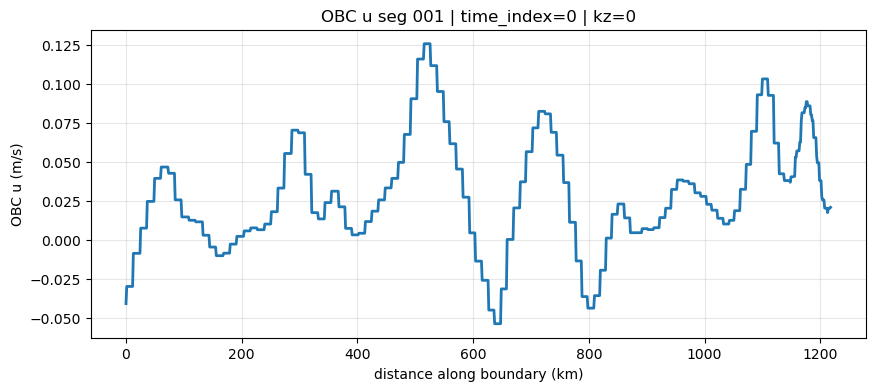

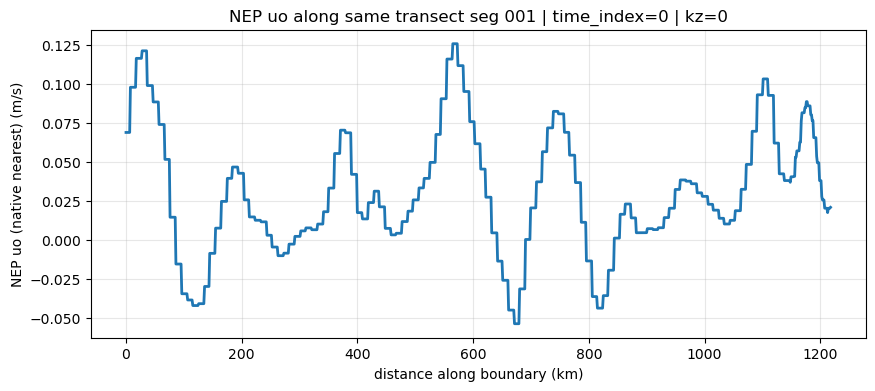

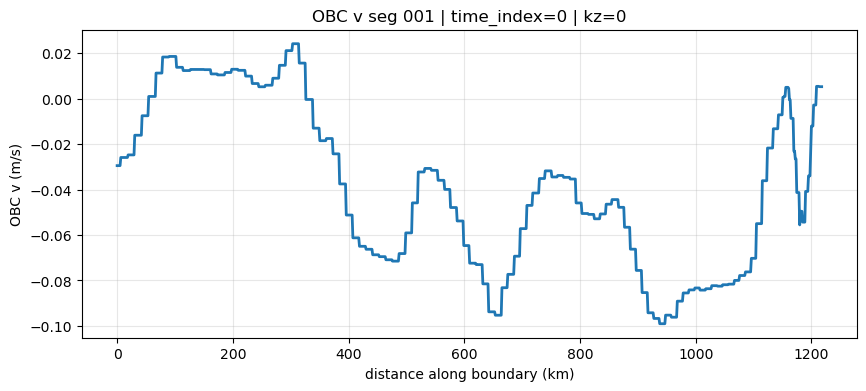

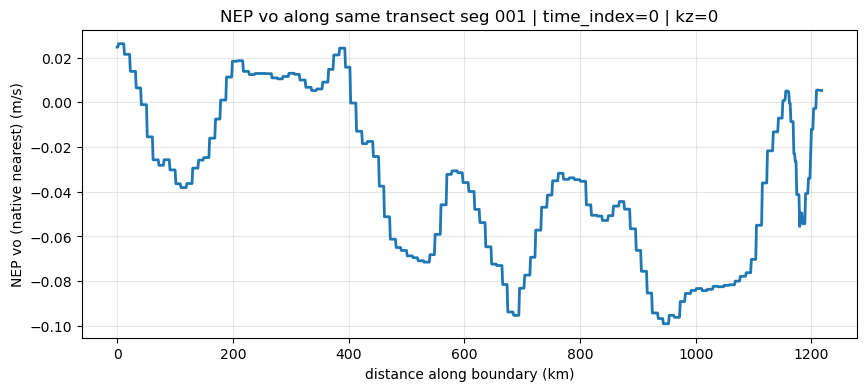

Stats (OBC - NEP native-nearest) at surface:
  u: mean/std/min/max = -0.0017045889981091022 0.04154049605131149 -0.12803485989570618 0.0905269905924797
  v: mean/std/min/max = -0.0017503105336800218 0.02386406622827053 -0.06689800322055817 0.055055297911167145


In [42]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ===== EDIT =====
year = 1994
time_index = 0
seg = "001"
kz = 0  # surface index (change to -1 if your z is reversed)

uv_obc_file = f"./outputs_CGOA_feb26_1D/uv_{int(seg):03d}.nc"  # uv_001.nc
nep_uv_file = f"/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/{year}0101crpt_forc/ocean_month_z.nc"

# ---------- helpers ----------
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_180_to_360(lon):
    lon = np.asarray(lon)
    return np.where(lon < 0, lon + 360.0, lon)

def haversine_km(lon, lat):
    R = 6371.0
    lonr = np.deg2rad(np.asarray(lon))
    latr = np.deg2rad(np.asarray(lat))
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate([[0], np.cumsum(d)])

def nearest_1d_index_sorted(grid, values):
    """grid must be 1D sorted ascending"""
    grid = np.asarray(grid)
    v = np.asarray(values)
    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)
    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    return (idx - 1) + choose_right.astype(int)

def pick_z_slice(da, kz):
    """Handle either z_l or z dim name."""
    if "z_l" in da.dims:
        return da.isel(z_l=kz)
    if "z" in da.dims:
        return da.isel(z=kz)
    raise ValueError(f"Could not find vertical dim in {da.dims}")

# ===== OPEN OBC uv =====
ds_o = xr.open_dataset(uv_obc_file, decode_times=True)

u_name   = _find_var(ds_o, [f"u_segment_{seg}", "u_segment_001", "u"])
v_name   = _find_var(ds_o, [f"v_segment_{seg}", "v_segment_001", "v"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

if any(v is None for v in [u_name, v_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in {uv_obc_file}. Vars={list(ds_o.variables)}")

# OBC surface u/v at boundary points
u_obc = ds_o[u_name].isel(time=time_index, nz_segment_001=kz).squeeze(drop=True).values.reshape(-1)
v_obc = ds_o[v_name].isel(time=time_index, nz_segment_001=kz).squeeze(drop=True).values.reshape(-1)
lon_o = ds_o[lon_name].values.reshape(-1)
lat_o = ds_o[lat_name].values.reshape(-1)

s_km = haversine_km(lon_o, lat_o)

# ===== OPEN NEP uv =====
ds_n = xr.open_dataset(nep_uv_file, decode_times=True)

uo2d = pick_z_slice(ds_n["uo"].isel(time=time_index), kz).values  # (yh,xq)
vo2d = pick_z_slice(ds_n["vo"].isel(time=time_index), kz).values  # (yq,xh)

# coords
xq = ds_n["xq"].values
yh = ds_n["yh"].values
xh = ds_n["xh"].values
yq = ds_n["yq"].values

# Match lon convention per grid
lon_for_u = lon_180_to_360(lon_o) if (np.nanmin(xq) >= 0 and np.nanmax(xq) > 180) else lon_o
lon_for_v = lon_180_to_360(lon_o) if (np.nanmin(xh) >= 0 and np.nanmax(xh) > 180) else lon_o

# Nearest indices
ix_u = nearest_1d_index_sorted(xq, lon_for_u)
iy_u = nearest_1d_index_sorted(yh, lat_o)

ix_v = nearest_1d_index_sorted(xh, lon_for_v)
iy_v = nearest_1d_index_sorted(yq, lat_o)

u_nep = uo2d[iy_u, ix_u]
v_nep = vo2d[iy_v, ix_v]

# ==========================
# FIG 1 – OBC u
# ==========================
plt.figure(figsize=(10,4))
plt.plot(s_km, u_obc, linewidth=2)
plt.xlabel("distance along boundary (km)")
plt.ylabel("OBC u (m/s)")
plt.title(f"OBC u seg {seg} | time_index={time_index} | kz={kz}")
plt.grid(True, alpha=0.3)
plt.show()

# ==========================
# FIG 2 – NEP uo (native-nearest)
# ==========================
plt.figure(figsize=(10,4))
plt.plot(s_km, u_nep, linewidth=2)
plt.xlabel("distance along boundary (km)")
plt.ylabel("NEP uo (native nearest) (m/s)")
plt.title(f"NEP uo along same transect seg {seg} | time_index={time_index} | kz={kz}")
plt.grid(True, alpha=0.3)
plt.show()

# ==========================
# FIG 3 – OBC v
# ==========================
plt.figure(figsize=(10,4))
plt.plot(s_km, v_obc, linewidth=2)
plt.xlabel("distance along boundary (km)")
plt.ylabel("OBC v (m/s)")
plt.title(f"OBC v seg {seg} | time_index={time_index} | kz={kz}")
plt.grid(True, alpha=0.3)
plt.show()

# ==========================
# FIG 4 – NEP vo (native-nearest)
# ==========================
plt.figure(figsize=(10,4))
plt.plot(s_km, v_nep, linewidth=2)
plt.xlabel("distance along boundary (km)")
plt.ylabel("NEP vo (native nearest) (m/s)")
plt.title(f"NEP vo along same transect seg {seg} | time_index={time_index} | kz={kz}")
plt.grid(True, alpha=0.3)
plt.show()

# Optional stats
du = u_obc - u_nep
dv = v_obc - v_nep
print("Stats (OBC - NEP native-nearest) at surface:")
print("  u: mean/std/min/max =", float(np.nanmean(du)), float(np.nanstd(du)), float(np.nanmin(du)), float(np.nanmax(du)))
print("  v: mean/std/min/max =", float(np.nanmean(dv)), float(np.nanstd(dv)), float(np.nanmin(dv)), float(np.nanmax(dv)))

/vftmp/Remi.Pages/pid218228/ipykernel_218434/2903104.py:76: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_n = xr.open_dataset(nep_uv_file, decode_times=True)


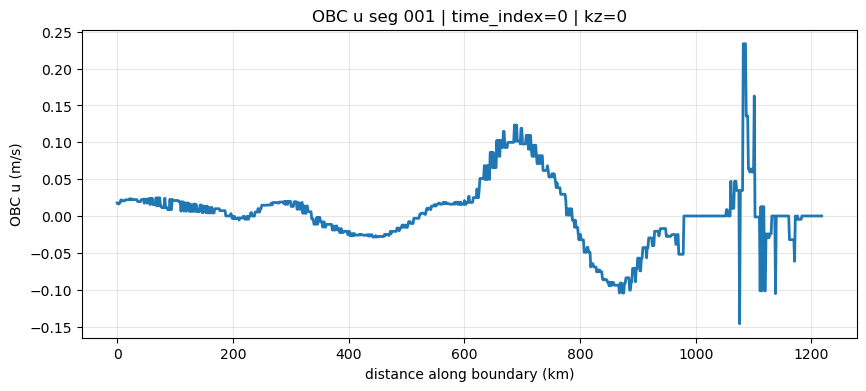

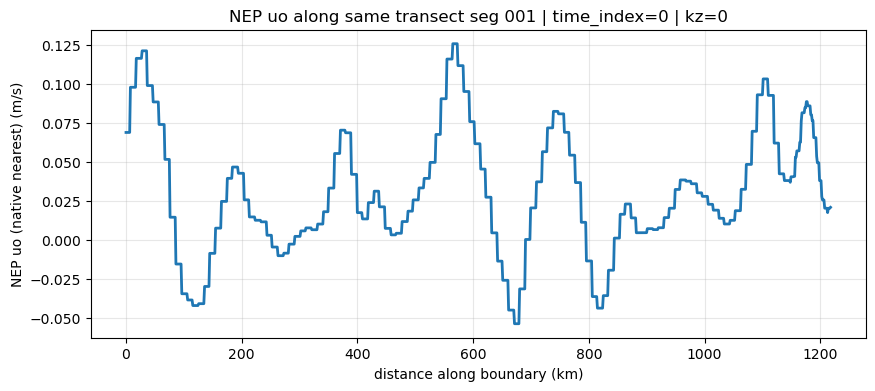

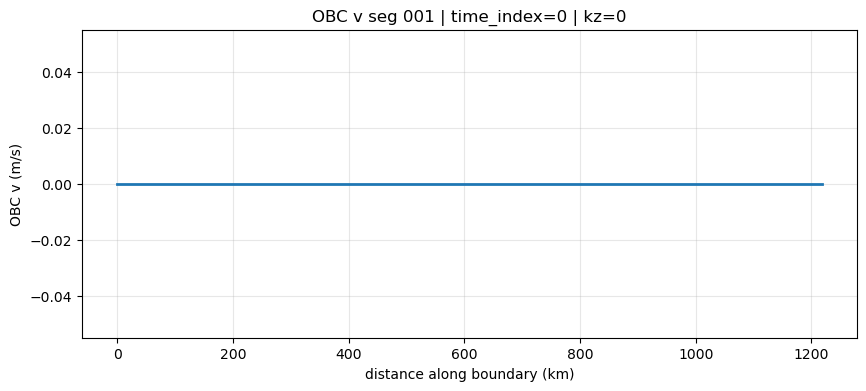

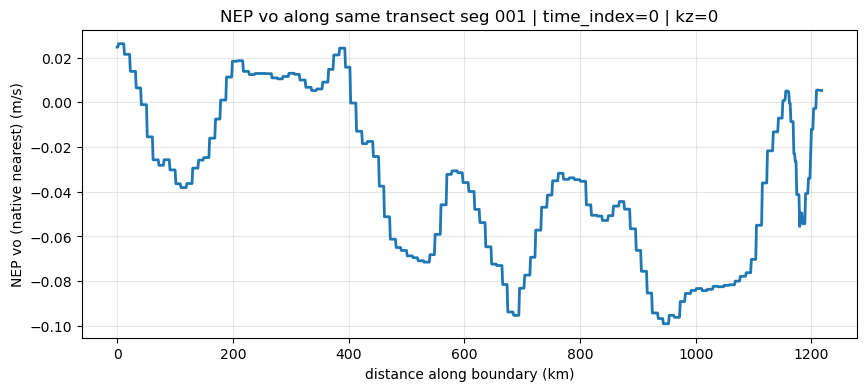

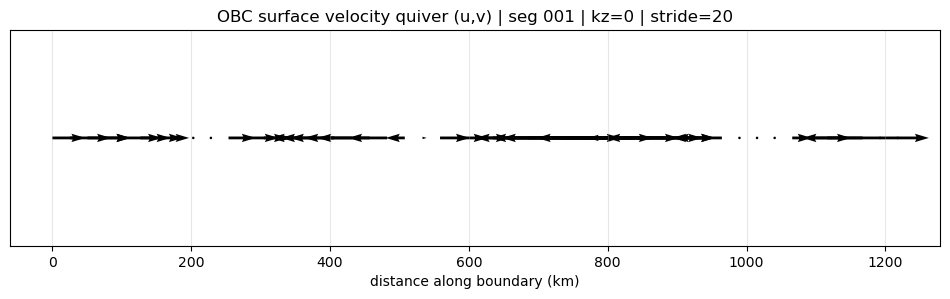

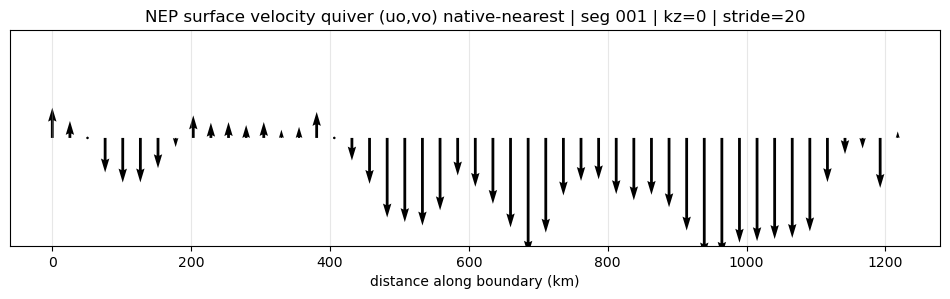

Speed stats (surface):
  OBC speed mean/std: 0.029832445085048676 0.03357239440083504
  NEP speed mean/std: 0.06407663971185684 0.03123648278415203


In [54]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ===== EDIT =====
year = 1994
time_index = 0
seg = "001"
kz = 0  # surface index (change to -1 if your z is reversed)

uv_obc_file = f"./outputs_CGOA_feb26/uv_{int(seg):03d}.nc"  # uv_001.nc
nep_uv_file = f"/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/{year}0101crpt_forc/ocean_month_z.nc"

# For quiver readability
stride = 20          # plot every Nth point
qscale = None        # None lets matplotlib choose; you can set e.g. 2.0 or 5.0
qwidth = 0.003       # arrow width

# ---------- helpers ----------
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_180_to_360(lon):
    lon = np.asarray(lon)
    return np.where(lon < 0, lon + 360.0, lon)

def haversine_km(lon, lat):
    R = 6371.0
    lonr = np.deg2rad(np.asarray(lon))
    latr = np.deg2rad(np.asarray(lat))
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate([[0], np.cumsum(d)])

def nearest_1d_index_sorted(grid, values):
    grid = np.asarray(grid)
    v = np.asarray(values)
    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)
    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    return (idx - 1) + choose_right.astype(int)

def pick_z_slice(da, kz):
    if "z_l" in da.dims:
        return da.isel(z_l=kz)
    if "z" in da.dims:
        return da.isel(z=kz)
    raise ValueError(f"Could not find vertical dim in {da.dims}")

# ===== OPEN OBC uv =====
ds_o = xr.open_dataset(uv_obc_file, decode_times=True)

u_name   = _find_var(ds_o, [f"u_segment_{seg}", "u_segment_001", "u"])
v_name   = _find_var(ds_o, [f"v_segment_{seg}", "v_segment_001", "v"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

if any(v is None for v in [u_name, v_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in {uv_obc_file}. Vars={list(ds_o.variables)}")

u_obc = ds_o[u_name].isel(time=time_index, nz_segment_001=kz).squeeze(drop=True).values.reshape(-1)
v_obc = ds_o[v_name].isel(time=time_index, nz_segment_001=kz).squeeze(drop=True).values.reshape(-1)
lon_o = ds_o[lon_name].values.reshape(-1)
lat_o = ds_o[lat_name].values.reshape(-1)

s_km = haversine_km(lon_o, lat_o)

# ===== OPEN NEP uv =====
ds_n = xr.open_dataset(nep_uv_file, decode_times=True)

uo2d = pick_z_slice(ds_n["uo"].isel(time=time_index), kz).values  # (yh,xq)
vo2d = pick_z_slice(ds_n["vo"].isel(time=time_index), kz).values  # (yq,xh)

xq = ds_n["xq"].values
yh = ds_n["yh"].values
xh = ds_n["xh"].values
yq = ds_n["yq"].values

lon_for_u = lon_180_to_360(lon_o) if (np.nanmin(xq) >= 0 and np.nanmax(xq) > 180) else lon_o
lon_for_v = lon_180_to_360(lon_o) if (np.nanmin(xh) >= 0 and np.nanmax(xh) > 180) else lon_o

ix_u = nearest_1d_index_sorted(xq, lon_for_u)
iy_u = nearest_1d_index_sorted(yh, lat_o)

ix_v = nearest_1d_index_sorted(xh, lon_for_v)
iy_v = nearest_1d_index_sorted(yq, lat_o)

u_nep = uo2d[iy_u, ix_u]
v_nep = vo2d[iy_v, ix_v]

# ==========================
# 4 line plots (like before)
# ==========================
plt.figure(figsize=(10,4))
plt.plot(s_km, u_obc, linewidth=2)
plt.xlabel("distance along boundary (km)")
plt.ylabel("OBC u (m/s)")
plt.title(f"OBC u seg {seg} | time_index={time_index} | kz={kz}")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(s_km, u_nep, linewidth=2)
plt.xlabel("distance along boundary (km)")
plt.ylabel("NEP uo (native nearest) (m/s)")
plt.title(f"NEP uo along same transect seg {seg} | time_index={time_index} | kz={kz}")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(s_km, v_obc, linewidth=2)
plt.xlabel("distance along boundary (km)")
plt.ylabel("OBC v (m/s)")
plt.title(f"OBC v seg {seg} | time_index={time_index} | kz={kz}")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(s_km, v_nep, linewidth=2)
plt.xlabel("distance along boundary (km)")
plt.ylabel("NEP vo (native nearest) (m/s)")
plt.title(f"NEP vo along same transect seg {seg} | time_index={time_index} | kz={kz}")
plt.grid(True, alpha=0.3)
plt.show()

# ==========================
# Quiver along the transect
# ==========================
idx = np.arange(0, len(s_km), stride)
y0 = np.zeros_like(idx, dtype=float)

# --- Figure: OBC quiver ---
plt.figure(figsize=(12, 2.8))
plt.quiver(
    s_km[idx], y0,
    u_obc[idx], v_obc[idx],
    angles="xy", scale_units="xy", scale=qscale,
    width=qwidth
)
plt.yticks([])
plt.xlabel("distance along boundary (km)")
plt.title(f"OBC surface velocity quiver (u,v) | seg {seg} | kz={kz} | stride={stride}")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

# --- Figure: NEP quiver ---
plt.figure(figsize=(12, 2.8))
plt.quiver(
    s_km[idx], y0,
    u_nep[idx], v_nep[idx],
    angles="xy", scale_units="xy", scale=qscale,
    width=qwidth
)
plt.yticks([])
plt.xlabel("distance along boundary (km)")
plt.title(f"NEP surface velocity quiver (uo,vo) native-nearest | seg {seg} | kz={kz} | stride={stride}")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

# Optional quick stats
spd_obc = np.sqrt(u_obc**2 + v_obc**2)
spd_nep = np.sqrt(u_nep**2 + v_nep**2)
print("Speed stats (surface):")
print("  OBC speed mean/std:", float(np.nanmean(spd_obc)), float(np.nanstd(spd_obc)))
print("  NEP speed mean/std:", float(np.nanmean(spd_nep)), float(np.nanstd(spd_nep)))

Flipping normal to enforce eastward inflow positive.


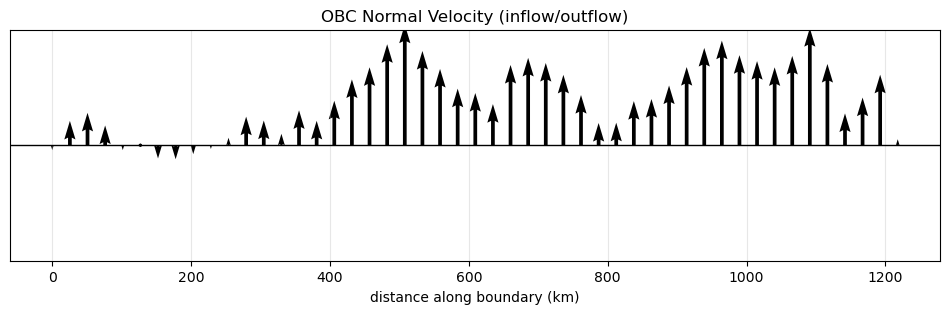

Normal velocity stats:
 mean: 0.047980279619296
 min : -0.016387053887137248
 max : 0.11691528730507436


In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Assume you already computed:
# s_km      -> distance along boundary
# lon_o     -> boundary lon
# lat_o     -> boundary lat
# u_obc     -> surface u
# v_obc     -> surface v
# (or use u_nep, v_nep)

stride = 20
qwidth = 0.004

# ---- compute boundary normal vectors ----
# Compute tangent vector along boundary
lonr = np.deg2rad(lon_o)
latr = np.deg2rad(lat_o)

# convert to local Cartesian (approx small-area)
dx = np.cos(latr) * np.gradient(lonr)
dy = np.gradient(latr)

# normalize tangent
mag = np.sqrt(dx**2 + dy**2)
tx = dx / mag
ty = dy / mag

# normal vector (rotate tangent 90°)
# (nx, ny) = (-ty, tx)
nx = -ty
ny = tx

# ---- project velocity onto boundary normal ----
Un_obc = u_obc * nx + v_obc * ny
# For NEP use:
# Un_nep = u_nep * nx + v_nep * ny
if np.nanmean(u_obc) * np.nanmean(Un_obc) < 0:
    print("Flipping normal to enforce eastward inflow positive.")
    nx = -nx
    ny = -ny
    Un_obc = -Un_obc
# ---- 1D quiver along transect ----
idx = np.arange(0, len(s_km), stride)
y0 = np.zeros_like(idx)

plt.figure(figsize=(12, 3))

plt.quiver(
    s_km[idx], y0,
    np.zeros_like(idx),      # no horizontal arrow
    Un_obc[idx],             # vertical arrow = inflow/outflow
    angles='xy',
    scale_units='xy',
    scale=None,
    width=qwidth
)

plt.axhline(0, color='k', linewidth=1)
plt.yticks([])
plt.xlabel("distance along boundary (km)")
plt.title("OBC Normal Velocity (inflow/outflow)")

plt.grid(True, axis='x', alpha=0.3)
plt.show()

print("Normal velocity stats:")
print(" mean:", np.nanmean(Un_obc))
print(" min :", np.nanmin(Un_obc))
print(" max :", np.nanmax(Un_obc))

In [46]:
print("Mean raw u:", np.nanmean(u_obc))
print("Mean normal velocity:", np.nanmean(Un_obc))

Mean raw u: 0.028038966
Mean normal velocity: -0.047980279619296


In [48]:
import numpy as np
import xarray as xr


import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ===== EDIT =====
year = 1994
time_index = 0
seg = "001"
kz = 0  # surface index (change to -1 if your z is reversed)

uv_obc_file = f"./outputs_CGOA_feb26_1D/uv_{int(seg):03d}.nc"  # uv_001.nc
nep_uv_file = f"/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/{year}0101crpt_forc/ocean_month_z.nc"

# For quiver readability
stride = 20          # plot every Nth point
qscale = None        # None lets matplotlib choose; you can set e.g. 2.0 or 5.0
qwidth = 0.003       # arrow width

# ---------- helpers ----------
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_180_to_360(lon):
    lon = np.asarray(lon)
    return np.where(lon < 0, lon + 360.0, lon)

def haversine_km(lon, lat):
    R = 6371.0
    lonr = np.deg2rad(np.asarray(lon))
    latr = np.deg2rad(np.asarray(lat))
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate([[0], np.cumsum(d)])

def nearest_1d_index_sorted(grid, values):
    grid = np.asarray(grid)
    v = np.asarray(values)
    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)
    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    return (idx - 1) + choose_right.astype(int)

def pick_z_slice(da, kz):
    if "z_l" in da.dims:
        return da.isel(z_l=kz)
    if "z" in da.dims:
        return da.isel(z=kz)
    raise ValueError(f"Could not find vertical dim in {da.dims}")

# ===== OPEN OBC uv =====
ds_o = xr.open_dataset(uv_obc_file, decode_times=True)

u_name   = _find_var(ds_o, [f"u_segment_{seg}", "u_segment_001", "u"])
v_name   = _find_var(ds_o, [f"v_segment_{seg}", "v_segment_001", "v"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

if any(v is None for v in [u_name, v_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in {uv_obc_file}. Vars={list(ds_o.variables)}")

u_obc = ds_o[u_name].isel(time=time_index, nz_segment_001=kz).squeeze(drop=True).values.reshape(-1)
v_obc = ds_o[v_name].isel(time=time_index, nz_segment_001=kz).squeeze(drop=True).values.reshape(-1)
lon_o = ds_o[lon_name].values.reshape(-1)
lat_o = ds_o[lat_name].values.reshape(-1)

s_km = haversine_km(lon_o, lat_o)

# ===== OPEN NEP uv =====
ds_n = xr.open_dataset(nep_uv_file, decode_times=True)

uo2d = pick_z_slice(ds_n["uo"].isel(time=time_index), kz).values  # (yh,xq)
vo2d = pick_z_slice(ds_n["vo"].isel(time=time_index), kz).values  # (yq,xh)

xq = ds_n["xq"].values
yh = ds_n["yh"].values
xh = ds_n["xh"].values
yq = ds_n["yq"].values

lon_for_u = lon_180_to_360(lon_o) if (np.nanmin(xq) >= 0 and np.nanmax(xq) > 180) else lon_o
lon_for_v = lon_180_to_360(lon_o) if (np.nanmin(xh) >= 0 and np.nanmax(xh) > 180) else lon_o

ix_u = nearest_1d_index_sorted(xq, lon_for_u)
iy_u = nearest_1d_index_sorted(yh, lat_o)

ix_v = nearest_1d_index_sorted(xh, lon_for_v)
iy_v = nearest_1d_index_sorted(yq, lat_o)

u_nep = uo2d[iy_u, ix_u]
v_nep = vo2d[iy_v, ix_v]

GOA_STATIC = "/archive/Remi.Pages/fre/Arc_12/2026_02.01/CGOA_BGC_2025_07_base_nep_phy_feb26/gfdl.ncrc6-intel23-prod/pp/ocean_daily/ocean_daily.static.nc"
obc_uv_file = "./outputs_CGOA_feb26_1D/uv_001.nc"  # seg001 east

def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_360_to_180(lon):
    lon = np.asarray(lon)
    return ((lon + 180) % 360) - 180

# --- load OBC points ---
ds_o = xr.open_dataset(obc_uv_file)
lon_name = _find_var(ds_o, ["lon_segment_001", "lon"])
lat_name = _find_var(ds_o, ["lat_segment_001", "lat"])
lon_o = ds_o[lon_name].values.reshape(-1)
lat_o = ds_o[lat_name].values.reshape(-1)

# --- build tangent/normal from the polyline ---
lonr = np.deg2rad(lon_o)
latr = np.deg2rad(lat_o)
dx = np.cos(latr) * np.gradient(lonr)
dy = np.gradient(latr)
mag = np.sqrt(dx**2 + dy**2)
tx, ty = dx/mag, dy/mag

# candidate normal (+)
nx, ny = -ty, tx   # candidate

# --- load GOA mask + coords (use tracer grid as example) ---
goa = xr.open_dataset(GOA_STATIC, decode_times=False)

# pick a wet mask + lon/lat that are on the SAME grid
# common names in MOM6 statics: geolon/geolat + wet
wet_name = _find_var(goa, ["wet", "wet_t", "wet_c", "wet_cell", "wet_tracer"])
lonT_name = _find_var(goa, ["geolon", "geolon_t", "geolon_c"])
latT_name = _find_var(goa, ["geolat", "geolat_t", "geolat_c"])
if any(v is None for v in [wet_name, lonT_name, latT_name]):
    raise ValueError(f"Could not find wet/lon/lat in GOA static. Vars: {list(goa.variables)}")

wet = np.array(goa[wet_name])
lonT = np.array(goa[lonT_name])
latT = np.array(goa[latT_name])

# nearest-2D helper
def nearest_2d(lon2d, lat2d, lon_pts, lat_pts, chunk=300):
    lonf = lon2d.ravel()
    latf = lat2d.ravel()
    out = np.empty(len(lon_pts), dtype=int)
    for k0 in range(0, len(lon_pts), chunk):
        k1 = min(len(lon_pts), k0+chunk)
        lp = lon_pts[k0:k1][:, None]
        ap = lat_pts[k0:k1][:, None]
        d2 = (lonf[None,:]-lp)**2 + (latf[None,:]-ap)**2
        out[k0:k1] = np.argmin(d2, axis=1)
    jj, ii = np.unravel_index(out, lon2d.shape)
    return jj, ii

# --- step test ---
# step size ~ 0.05 deg (~5 km). tune if needed
step_deg = 0.05
lon_in = lon_o + step_deg * nx
lat_in = lat_o + step_deg * ny

# handle lon convention mismatch between lonT and lon_o
# (convert both to -180..180 for the nearest search)
lonT180 = lon_360_to_180(lonT)
lon_in180 = lon_360_to_180(lon_in)

jj, ii = nearest_2d(lonT180, latT, lon_in180, lat_in)
inside = wet[jj, ii] > 0.5

frac_inside = np.mean(inside[np.isfinite(inside)])
print("Fraction of +normal steps landing in WET GOA:", frac_inside)

if frac_inside < 0.5:
    print("=> +normal points OUT of domain, flipping.")
    nx, ny = -nx, -ny
else:
    print("=> +normal points INTO domain (keep).")

Fraction of +normal steps landing in WET GOA: 0.0
=> +normal points OUT of domain, flipping.


/vftmp/Remi.Pages/pid218228/ipykernel_218434/2814607579.py:76: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_n = xr.open_dataset(nep_uv_file, decode_times=True)


Fraction of +normal steps landing in WET GOA: 0.0
=> +normal points OUT of domain, flipping so Un>0 means INTO GOA.
After sign choice, fraction WET: 0.0


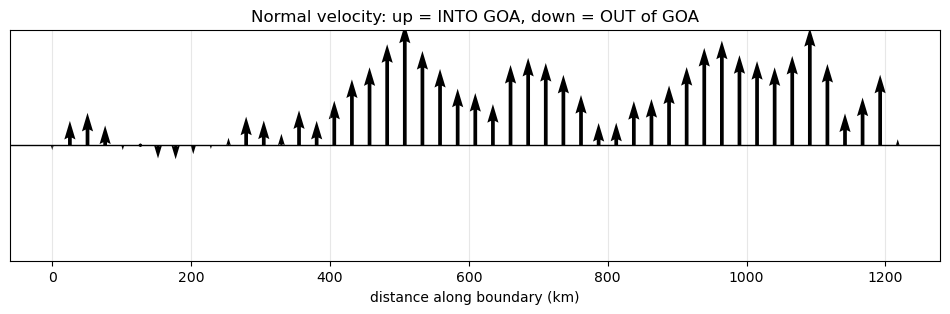

Normal velocity stats (Un>0 INTO GOA):
  mean: 0.047980279619296
  min : -0.016387053887137248
  max : 0.11691528730507436


In [52]:

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ===== EDIT =====
year = 1994
time_index = 0
seg = "001"
kz = 0  # surface index (change to -1 if your z is reversed)

uv_obc_file = f"./outputs_CGOA_feb26_1D/uv_{int(seg):03d}.nc"  # uv_001.nc
nep_uv_file = f"/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/{year}0101crpt_forc/ocean_month_z.nc"

# For quiver readability
stride = 20          # plot every Nth point
qscale = None        # None lets matplotlib choose; you can set e.g. 2.0 or 5.0
qwidth = 0.003       # arrow width

# ---------- helpers ----------
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_180_to_360(lon):
    lon = np.asarray(lon)
    return np.where(lon < 0, lon + 360.0, lon)

def haversine_km(lon, lat):
    R = 6371.0
    lonr = np.deg2rad(np.asarray(lon))
    latr = np.deg2rad(np.asarray(lat))
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate([[0], np.cumsum(d)])

def nearest_1d_index_sorted(grid, values):
    grid = np.asarray(grid)
    v = np.asarray(values)
    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)
    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    return (idx - 1) + choose_right.astype(int)

def pick_z_slice(da, kz):
    if "z_l" in da.dims:
        return da.isel(z_l=kz)
    if "z" in da.dims:
        return da.isel(z=kz)
    raise ValueError(f"Could not find vertical dim in {da.dims}")

# ===== OPEN OBC uv =====
ds_o = xr.open_dataset(uv_obc_file, decode_times=True)

u_name   = _find_var(ds_o, [f"u_segment_{seg}", "u_segment_001", "u"])
v_name   = _find_var(ds_o, [f"v_segment_{seg}", "v_segment_001", "v"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

if any(v is None for v in [u_name, v_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in {uv_obc_file}. Vars={list(ds_o.variables)}")

u_obc = ds_o[u_name].isel(time=time_index, nz_segment_001=kz).squeeze(drop=True).values.reshape(-1)
v_obc = ds_o[v_name].isel(time=time_index, nz_segment_001=kz).squeeze(drop=True).values.reshape(-1)
lon_o = ds_o[lon_name].values.reshape(-1)
lat_o = ds_o[lat_name].values.reshape(-1)

s_km = haversine_km(lon_o, lat_o)

# ===== OPEN NEP uv =====
ds_n = xr.open_dataset(nep_uv_file, decode_times=True)

uo2d = pick_z_slice(ds_n["uo"].isel(time=time_index), kz).values  # (yh,xq)
vo2d = pick_z_slice(ds_n["vo"].isel(time=time_index), kz).values  # (yq,xh)

xq = ds_n["xq"].values
yh = ds_n["yh"].values
xh = ds_n["xh"].values
yq = ds_n["yq"].values

lon_for_u = lon_180_to_360(lon_o) if (np.nanmin(xq) >= 0 and np.nanmax(xq) > 180) else lon_o
lon_for_v = lon_180_to_360(lon_o) if (np.nanmin(xh) >= 0 and np.nanmax(xh) > 180) else lon_o

ix_u = nearest_1d_index_sorted(xq, lon_for_u)
iy_u = nearest_1d_index_sorted(yh, lat_o)

ix_v = nearest_1d_index_sorted(xh, lon_for_v)
iy_v = nearest_1d_index_sorted(yq, lat_o)

u_nep = uo2d[iy_u, ix_u]
v_nep = vo2d[iy_v, ix_v]


# =========================
# REQUIRED inputs you already have:
# s_km, lon_o, lat_o, u_obc, v_obc
# =========================

# ===== EDIT =====
GOA_STATIC = "/archive/Remi.Pages/fre/Arc_12/2026_02.01/CGOA_BGC_2025_07_base_nep_phy_feb26/gfdl.ncrc6-intel23-prod/pp/ocean_daily/ocean_daily.static.nc"

stride  = 20
qwidth  = 0.004
step_deg = 0.05   # try 0.01 if you are near coast / narrow passages

# ---------- helpers ----------
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_360_to_180(lon):
    lon = np.asarray(lon)
    return ((lon + 180) % 360) - 180

def nearest_2d(lon2d, lat2d, lon_pts, lat_pts, chunk=300):
    lonf = lon2d.ravel()
    latf = lat2d.ravel()
    out = np.empty(len(lon_pts), dtype=int)
    for k0 in range(0, len(lon_pts), chunk):
        k1 = min(len(lon_pts), k0 + chunk)
        lp = lon_pts[k0:k1][:, None]
        ap = lat_pts[k0:k1][:, None]
        d2 = (lonf[None, :] - lp) ** 2 + (latf[None, :] - ap) ** 2
        out[k0:k1] = np.argmin(d2, axis=1)
    jj, ii = np.unravel_index(out, lon2d.shape)
    return jj, ii

# =========================
# 1) Compute tangent + candidate normal
# =========================
lonr = np.deg2rad(lon_o)
latr = np.deg2rad(lat_o)

dx = np.cos(latr) * np.gradient(lonr)
dy = np.gradient(latr)

mag = np.sqrt(dx**2 + dy**2)
tx = dx / mag
ty = dy / mag

# candidate normal (+)
nx = -ty
ny =  tx

# =========================
# 2) Decide sign using GOA wet-mask step test
# =========================
goa = xr.open_dataset(GOA_STATIC, decode_times=False)

wet_name  = _find_var(goa, ["wet", "wet_t", "wet_c", "wet_cell", "wet_tracer"])
lonT_name = _find_var(goa, ["geolon", "geolon_t", "geolon_c"])
latT_name = _find_var(goa, ["geolat", "geolat_t", "geolat_c"])

if any(v is None for v in [wet_name, lonT_name, latT_name]):
    raise ValueError(
        "Could not find wet/geolon/geolat in GOA static. "
        f"Found wet={wet_name}, lon={lonT_name}, lat={latT_name}. "
        f"Vars={list(goa.variables)}"
    )

wet = goa[wet_name]
lonT = goa[lonT_name]
latT = goa[latT_name]

# if wet is 3D (e.g. z), take surface
if wet.ndim > 2:
    # choose first index along extra dims
    wet = wet.isel({d: 0 for d in wet.dims if d not in lonT.dims})

wet = np.array(wet)
lonT = np.array(lonT)
latT = np.array(latT)

# convert both to -180..180 for the nearest search
lonT180 = lon_360_to_180(lonT)

# step along +normal
lon_in = lon_o + step_deg * nx
lat_in = lat_o + step_deg * ny
lon_in180 = lon_360_to_180(lon_in)

jj, ii = nearest_2d(lonT180, latT, lon_in180, lat_in)
inside = wet[jj, ii] > 0.5
frac_inside = float(np.mean(inside[np.isfinite(inside)]))

print("Fraction of +normal steps landing in WET GOA:", frac_inside)

if frac_inside < 0.5:
    print("=> +normal points OUT of domain, flipping so Un>0 means INTO GOA.")
    nx = -nx
    ny = -ny
else:
    print("=> +normal points INTO domain, keeping so Un>0 means INTO GOA.")

# (Optional) verify after flip
lon_in2 = lon_o + step_deg * nx
lat_in2 = lat_o + step_deg * ny
jj2, ii2 = nearest_2d(lonT180, latT, lon_360_to_180(lon_in2), lat_in2)
inside2 = wet[jj2, ii2] > 0.5
print("After sign choice, fraction WET:", float(np.mean(inside2[np.isfinite(inside2)])))

# =========================
# 3) Project velocity onto inward normal
# =========================
Un_obc = u_obc * nx + v_obc * ny   # by construction: Un>0 INTO GOA

# =========================
# 4) 1D vertical quiver (up=in, down=out)
# =========================
idx = np.arange(0, len(s_km), stride)
y0 = np.zeros_like(idx, dtype=float)

plt.figure(figsize=(12, 3))
plt.quiver(
    s_km[idx], y0,
    np.zeros_like(idx),   # no horizontal arrow
    Un_obc[idx],          # vertical arrow = inflow/outflow
    angles="xy",
    scale_units="xy",
    scale=None,
    width=qwidth,
)
plt.axhline(0, color="k", linewidth=1)
plt.yticks([])
plt.xlabel("distance along boundary (km)")
plt.title("Normal velocity: up = INTO GOA, down = OUT of GOA")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

print("Normal velocity stats (Un>0 INTO GOA):")
print("  mean:", float(np.nanmean(Un_obc)))
print("  min :", float(np.nanmin(Un_obc)))
print("  max :", float(np.nanmax(Un_obc)))

/vftmp/Remi.Pages/pid218228/ipykernel_218434/3415031102.py:76: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_n = xr.open_dataset(nep_uv_file, decode_times=True)


Fraction of +normal steps landing in WET GOA: 0.0
=> +normal points OUT of domain, flipping so Un>0 means INTO GOA.
After sign choice, fraction WET: 0.0


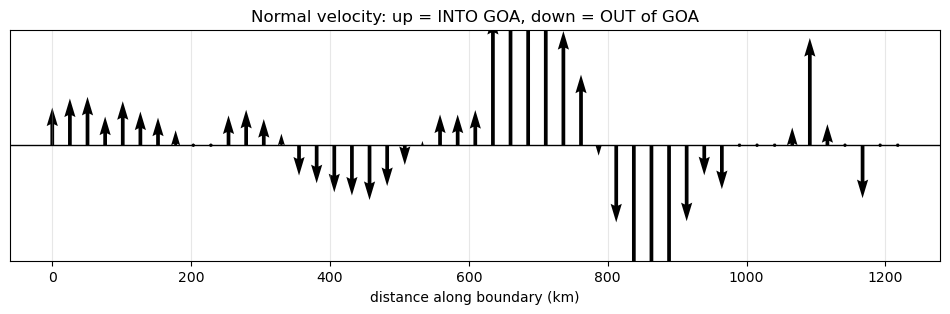

Normal velocity stats (Un>0 INTO GOA):
  mean: 0.002697585300410957
  min : -0.076208090500955
  max : 0.12156493544900675


In [53]:

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ===== EDIT =====
year = 1994
time_index = 0
seg = "001"
kz = 0  # surface index (change to -1 if your z is reversed)

uv_obc_file = f"./outputs_CGOA_feb26/uv_{int(seg):03d}.nc"  # uv_001.nc
nep_uv_file = f"/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/{year}0101crpt_forc/ocean_month_z.nc"

# For quiver readability
stride = 20          # plot every Nth point
qscale = None        # None lets matplotlib choose; you can set e.g. 2.0 or 5.0
qwidth = 0.003       # arrow width

# ---------- helpers ----------
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_180_to_360(lon):
    lon = np.asarray(lon)
    return np.where(lon < 0, lon + 360.0, lon)

def haversine_km(lon, lat):
    R = 6371.0
    lonr = np.deg2rad(np.asarray(lon))
    latr = np.deg2rad(np.asarray(lat))
    dlon = np.diff(lonr)
    dlat = np.diff(latr)
    a = np.sin(dlat/2)**2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon/2)**2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate([[0], np.cumsum(d)])

def nearest_1d_index_sorted(grid, values):
    grid = np.asarray(grid)
    v = np.asarray(values)
    idx = np.searchsorted(grid, v)
    idx = np.clip(idx, 1, len(grid) - 1)
    left = grid[idx - 1]
    right = grid[idx]
    choose_right = (np.abs(v - right) < np.abs(v - left))
    return (idx - 1) + choose_right.astype(int)

def pick_z_slice(da, kz):
    if "z_l" in da.dims:
        return da.isel(z_l=kz)
    if "z" in da.dims:
        return da.isel(z=kz)
    raise ValueError(f"Could not find vertical dim in {da.dims}")

# ===== OPEN OBC uv =====
ds_o = xr.open_dataset(uv_obc_file, decode_times=True)

u_name   = _find_var(ds_o, [f"u_segment_{seg}", "u_segment_001", "u"])
v_name   = _find_var(ds_o, [f"v_segment_{seg}", "v_segment_001", "v"])
lon_name = _find_var(ds_o, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
lat_name = _find_var(ds_o, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

if any(v is None for v in [u_name, v_name, lon_name, lat_name]):
    raise ValueError(f"Missing vars in {uv_obc_file}. Vars={list(ds_o.variables)}")

u_obc = ds_o[u_name].isel(time=time_index, nz_segment_001=kz).squeeze(drop=True).values.reshape(-1)
v_obc = ds_o[v_name].isel(time=time_index, nz_segment_001=kz).squeeze(drop=True).values.reshape(-1)
lon_o = ds_o[lon_name].values.reshape(-1)
lat_o = ds_o[lat_name].values.reshape(-1)

s_km = haversine_km(lon_o, lat_o)

# ===== OPEN NEP uv =====
ds_n = xr.open_dataset(nep_uv_file, decode_times=True)

uo2d = pick_z_slice(ds_n["uo"].isel(time=time_index), kz).values  # (yh,xq)
vo2d = pick_z_slice(ds_n["vo"].isel(time=time_index), kz).values  # (yq,xh)

xq = ds_n["xq"].values
yh = ds_n["yh"].values
xh = ds_n["xh"].values
yq = ds_n["yq"].values

lon_for_u = lon_180_to_360(lon_o) if (np.nanmin(xq) >= 0 and np.nanmax(xq) > 180) else lon_o
lon_for_v = lon_180_to_360(lon_o) if (np.nanmin(xh) >= 0 and np.nanmax(xh) > 180) else lon_o

ix_u = nearest_1d_index_sorted(xq, lon_for_u)
iy_u = nearest_1d_index_sorted(yh, lat_o)

ix_v = nearest_1d_index_sorted(xh, lon_for_v)
iy_v = nearest_1d_index_sorted(yq, lat_o)

u_nep = uo2d[iy_u, ix_u]
v_nep = vo2d[iy_v, ix_v]


# =========================
# REQUIRED inputs you already have:
# s_km, lon_o, lat_o, u_obc, v_obc
# =========================

# ===== EDIT =====
GOA_STATIC = "/archive/Remi.Pages/fre/Arc_12/2026_02.01/CGOA_BGC_2025_07_base_nep_phy_feb26/gfdl.ncrc6-intel23-prod/pp/ocean_daily/ocean_daily.static.nc"

stride  = 20
qwidth  = 0.004
step_deg = 0.05   # try 0.01 if you are near coast / narrow passages

# ---------- helpers ----------
def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def lon_360_to_180(lon):
    lon = np.asarray(lon)
    return ((lon + 180) % 360) - 180

def nearest_2d(lon2d, lat2d, lon_pts, lat_pts, chunk=300):
    lonf = lon2d.ravel()
    latf = lat2d.ravel()
    out = np.empty(len(lon_pts), dtype=int)
    for k0 in range(0, len(lon_pts), chunk):
        k1 = min(len(lon_pts), k0 + chunk)
        lp = lon_pts[k0:k1][:, None]
        ap = lat_pts[k0:k1][:, None]
        d2 = (lonf[None, :] - lp) ** 2 + (latf[None, :] - ap) ** 2
        out[k0:k1] = np.argmin(d2, axis=1)
    jj, ii = np.unravel_index(out, lon2d.shape)
    return jj, ii

# =========================
# 1) Compute tangent + candidate normal
# =========================
lonr = np.deg2rad(lon_o)
latr = np.deg2rad(lat_o)

dx = np.cos(latr) * np.gradient(lonr)
dy = np.gradient(latr)

mag = np.sqrt(dx**2 + dy**2)
tx = dx / mag
ty = dy / mag

# candidate normal (+)
nx = -ty
ny =  tx

# =========================
# 2) Decide sign using GOA wet-mask step test
# =========================
goa = xr.open_dataset(GOA_STATIC, decode_times=False)

wet_name  = _find_var(goa, ["wet", "wet_t", "wet_c", "wet_cell", "wet_tracer"])
lonT_name = _find_var(goa, ["geolon", "geolon_t", "geolon_c"])
latT_name = _find_var(goa, ["geolat", "geolat_t", "geolat_c"])

if any(v is None for v in [wet_name, lonT_name, latT_name]):
    raise ValueError(
        "Could not find wet/geolon/geolat in GOA static. "
        f"Found wet={wet_name}, lon={lonT_name}, lat={latT_name}. "
        f"Vars={list(goa.variables)}"
    )

wet = goa[wet_name]
lonT = goa[lonT_name]
latT = goa[latT_name]

# if wet is 3D (e.g. z), take surface
if wet.ndim > 2:
    # choose first index along extra dims
    wet = wet.isel({d: 0 for d in wet.dims if d not in lonT.dims})

wet = np.array(wet)
lonT = np.array(lonT)
latT = np.array(latT)

# convert both to -180..180 for the nearest search
lonT180 = lon_360_to_180(lonT)

# step along +normal
lon_in = lon_o + step_deg * nx
lat_in = lat_o + step_deg * ny
lon_in180 = lon_360_to_180(lon_in)

jj, ii = nearest_2d(lonT180, latT, lon_in180, lat_in)
inside = wet[jj, ii] > 0.5
frac_inside = float(np.mean(inside[np.isfinite(inside)]))

print("Fraction of +normal steps landing in WET GOA:", frac_inside)

if frac_inside < 0.5:
    print("=> +normal points OUT of domain, flipping so Un>0 means INTO GOA.")
    nx = -nx
    ny = -ny
else:
    print("=> +normal points INTO domain, keeping so Un>0 means INTO GOA.")

# (Optional) verify after flip
lon_in2 = lon_o + step_deg * nx
lat_in2 = lat_o + step_deg * ny
jj2, ii2 = nearest_2d(lonT180, latT, lon_360_to_180(lon_in2), lat_in2)
inside2 = wet[jj2, ii2] > 0.5
print("After sign choice, fraction WET:", float(np.mean(inside2[np.isfinite(inside2)])))

# =========================
# 3) Project velocity onto inward normal
# =========================
Un_obc = u_obc * nx + v_obc * ny   # by construction: Un>0 INTO GOA

# =========================
# 4) 1D vertical quiver (up=in, down=out)
# =========================
idx = np.arange(0, len(s_km), stride)
y0 = np.zeros_like(idx, dtype=float)

plt.figure(figsize=(12, 3))
plt.quiver(
    s_km[idx], y0,
    np.zeros_like(idx),   # no horizontal arrow
    Un_obc[idx],          # vertical arrow = inflow/outflow
    angles="xy",
    scale_units="xy",
    scale=None,
    width=qwidth,
)
plt.axhline(0, color="k", linewidth=1)
plt.yticks([])
plt.xlabel("distance along boundary (km)")
plt.title("Normal velocity: up = INTO GOA, down = OUT of GOA")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

print("Normal velocity stats (Un>0 INTO GOA):")
print("  mean:", float(np.nanmean(Un_obc)))
print("  min :", float(np.nanmin(Un_obc)))
print("  max :", float(np.nanmax(Un_obc)))